# State Space Control

In [1]:
import requests as req, os
import importlib.util

URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]

if not os.path.isfile(File[0]):
    print('Basic files not` found - downloading it')
    for dfile in File:
        if not os.path.isfile(dfile):
            print(dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()

print('Basic file found')
%run basic_material.py

j = complex(0,1)

from scipy.signal import butter
from control.matlab import tf, ss, ss2tf, bode, step, initial, lsim, margin, impulse, place, rlocus, lqr
from control_materials import *


Basic file found
Running Python: 3.8.17
Running Sympy: 1.12
Control Package Found


## State Space Topic 22

Nbar =-15.00


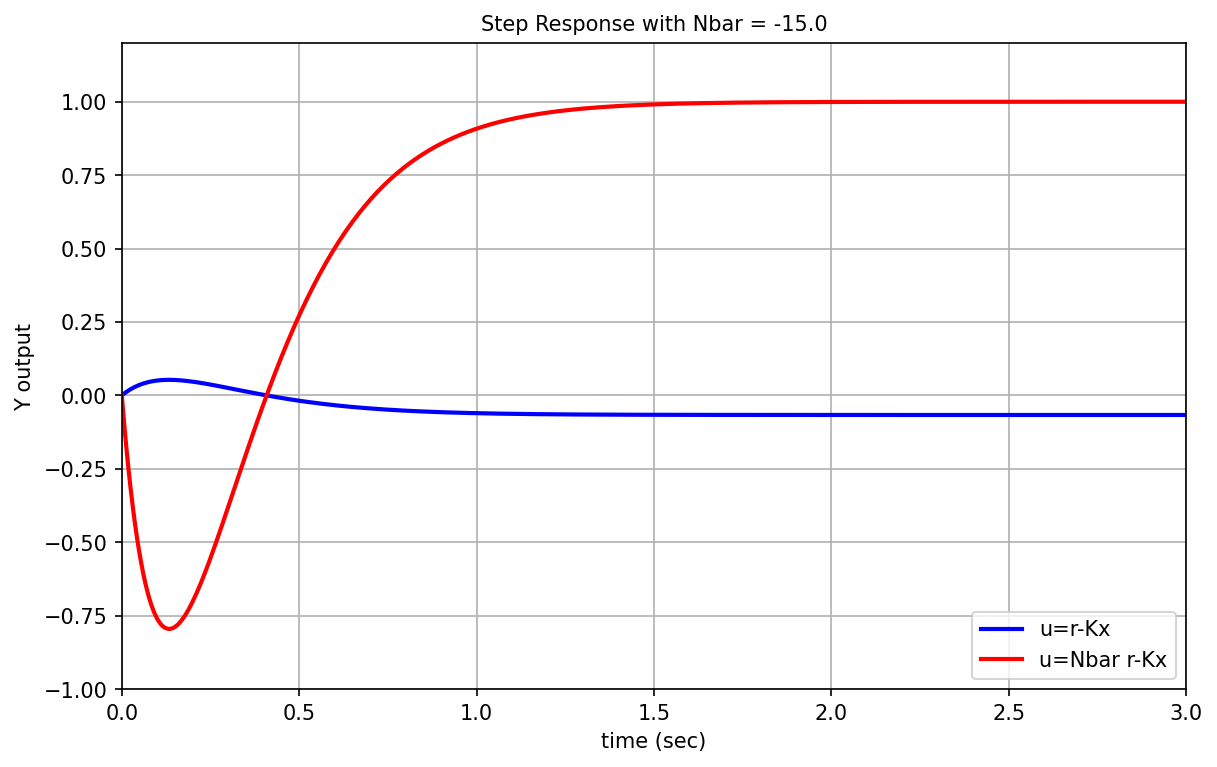

In [2]:
# full state feedback for topic 22
# reference input issues
#
a = np.array([[1, 1],[1, 2]])
nx = np.shape(a)[0]
b = np.array([1, 0]).reshape(nx,1)
c = np.array([1, 0])
d = 0

p = np.array([-5, -6])
# gains assumed found
k = place(a, b, p)

Nbar = float(1/(-c@np.linalg.inv(a-b*k)@b)[0][0])
print(f"{Nbar =: 4.2f}")
sys1 = ss(a-b*k,b,c,d)
sys2 = ss(a-b*k,b*Nbar,c,d)

t = np.linspace(0,3,500)
y,t = step(sys1,t)
y2,t2 = step(sys2,t)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y,'b-',label='u=r-Kx')
plt.plot(t2,y2,'r-',lw=2,label='u=Nbar r-Kx')
plt.axis([0, max(t), -1, 1.2])
plt.legend(loc=4)
plt.xlabel('time (sec)')
plt.ylabel('Y output')
plt.title('Step Response with'+f" {Nbar = : 3.1f}")
savefig("figs/Nbar.pdf", dpi=600)
plt.show()

## FSFB Place

In [3]:
def FSFB_place(G,pr,file_name='temp',w=np.logspace(-1,2,400),Tmax=1):
    nx = G.A.shape[0]

    k0 = place(G.A,G.B,pr)
    #
    # For state space for G_c(s)
    #
    # find the feedforward gains
    Nbar0 = float(np.linalg.inv(-G.C*np.linalg.inv(G.A-G.B*k0)*G.B))

    sys0 = ss(G.A-G.B*k0,G.B,G.C,G.D);
    sys1 = ss(G.A-G.B*k0,G.B*Nbar0,G.C,G.D);

    if file_name == 'examp1':
        w = np.logspace(0,3,400)
    if file_name == 'examp2':
        w = np.logspace(-3,1,400)
    if file_name == 'examp3':
        w = np.logspace(-1,2,400)
    else:
        w = np.logspace(-2,2,400)
    Gf = G(w*j)
    sys0f = sys0(j*w)
    sys1f = sys1(j*w)

    t = np.arange(0,Tmax,.01)    
    y0,t0 = step(sys0,T=t)
    y1,t1 = step(sys1,T=t)

    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax.plot(t0,y0,'g-',label=r'$u=r-Kx$')
    ax.plot(t1,y1,'r-',label=r'$u=Nr-Kx$')
    plt.legend()
    plt.text(max(t0)/2,.8,f"{Nbar0 =:3.1f}")
    plt.ylabel("Response")
    plt.ylabel("Time")
    savefig("figs/FSFB_pl"+file_name+"_0.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(sys0f),'g',label=r'$u=r-Kx$')
    ax[1].semilogx(w,np.unwrap(np.angle(sys0f))*r2d,'g',label=r'$u=r-Kx$')
    ax[0].loglog(w,np.abs(sys1f),'r',label=r'$u=Nr-Kx$')
    ax[1].semilogx(w,np.unwrap(np.angle(sys1f))*r2d,'r',label=r'$u=Nr-Kx$')

    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    ax[1].axhline(y=-180,c='k',ls='--')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    savefig("figs/FSFB_pl"+file_name+"_1.pdf", dpi=600)
    plt.show()

    return k0

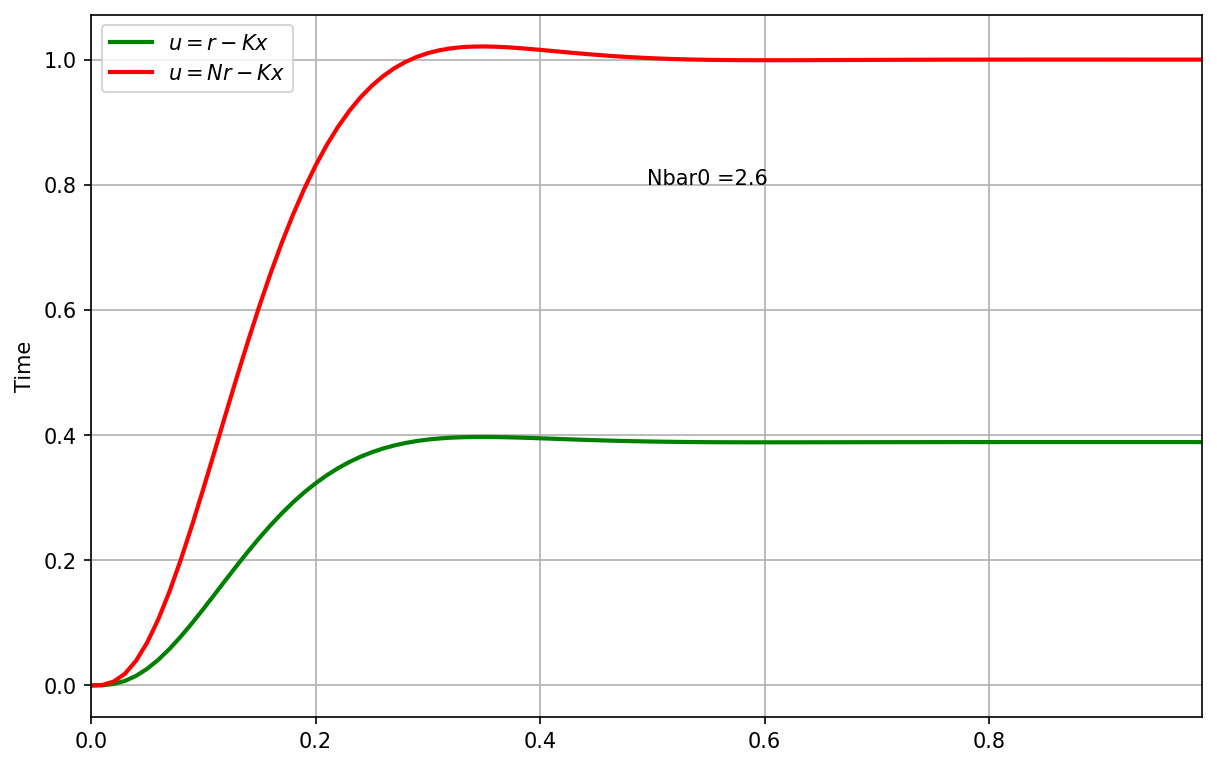

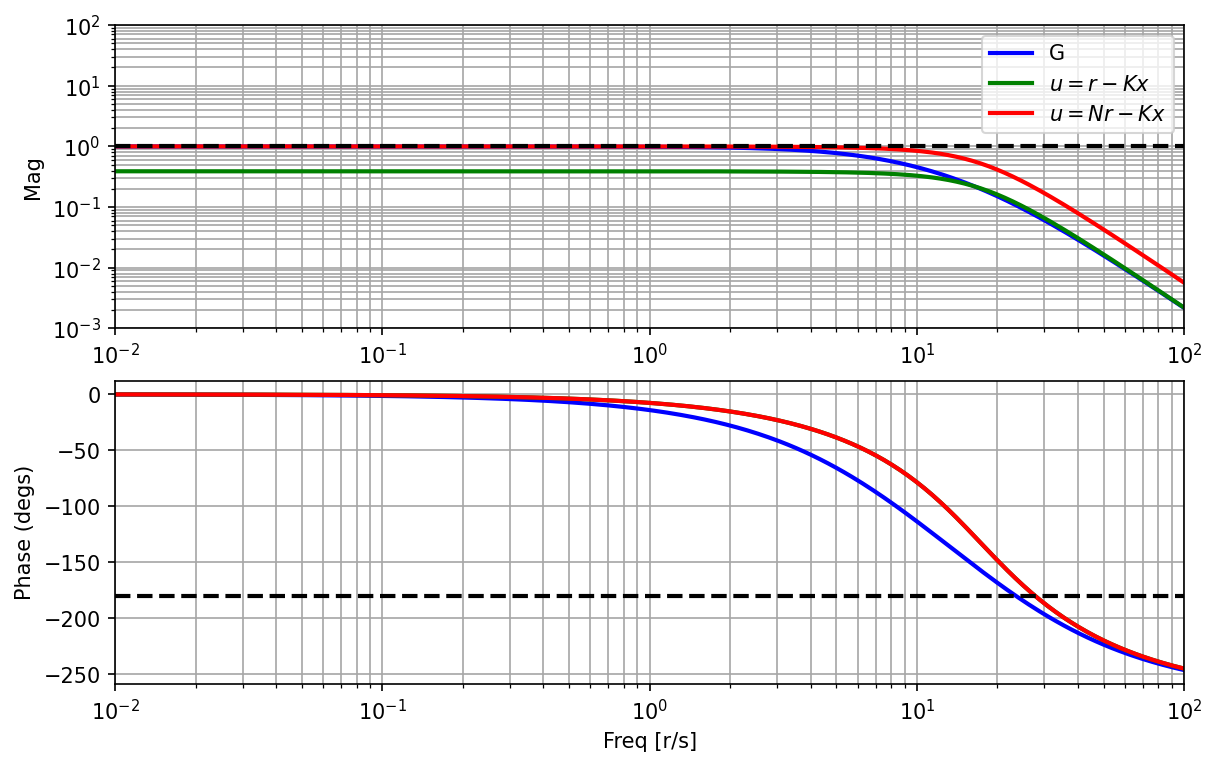

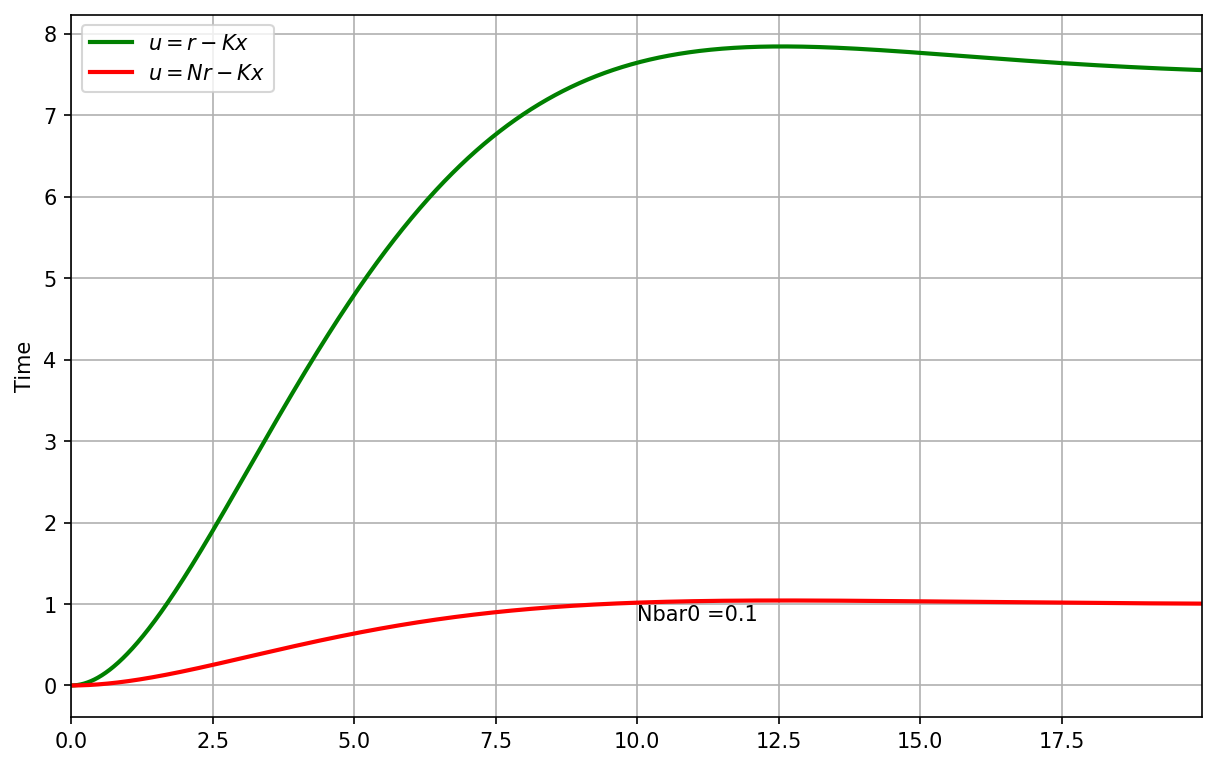

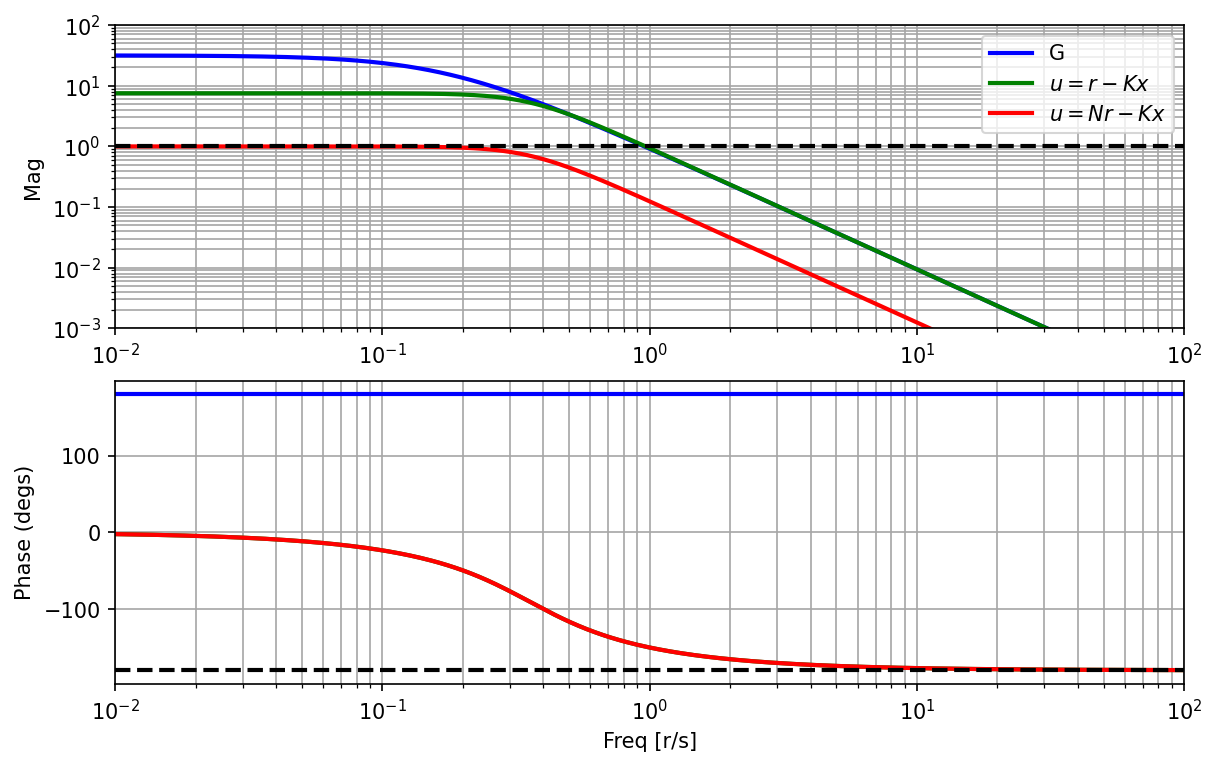

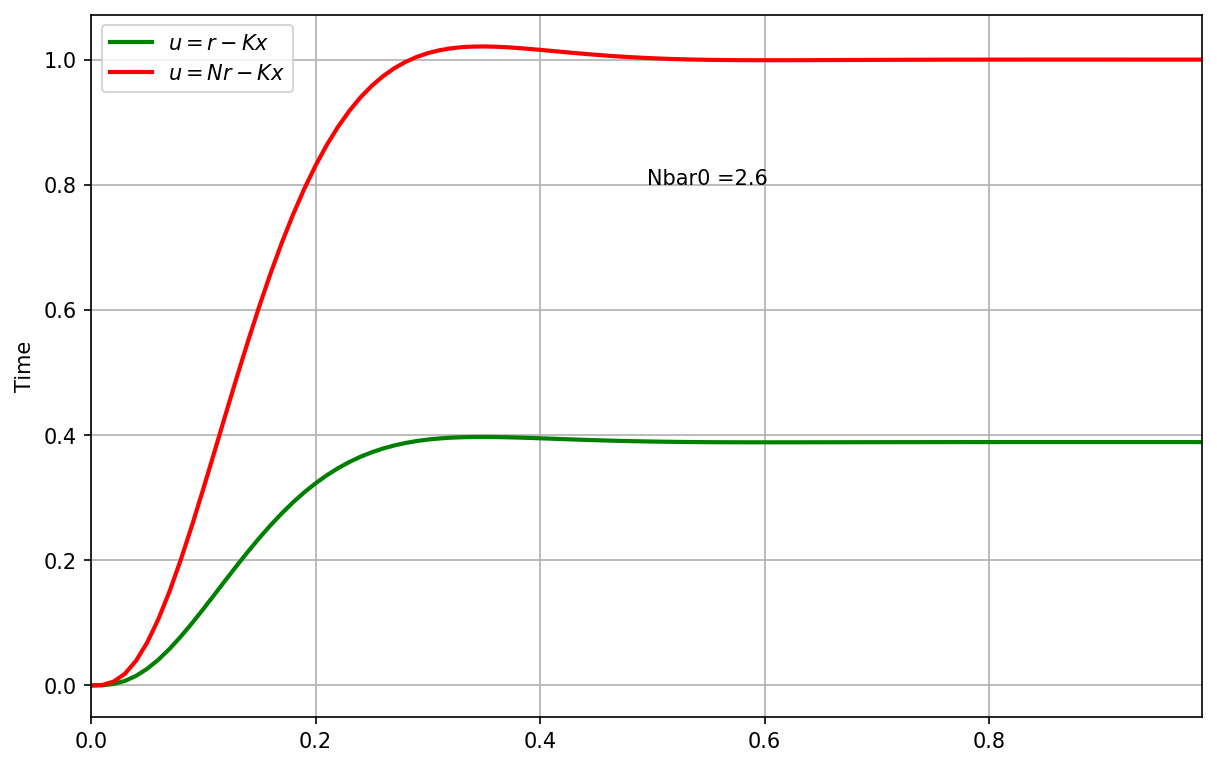

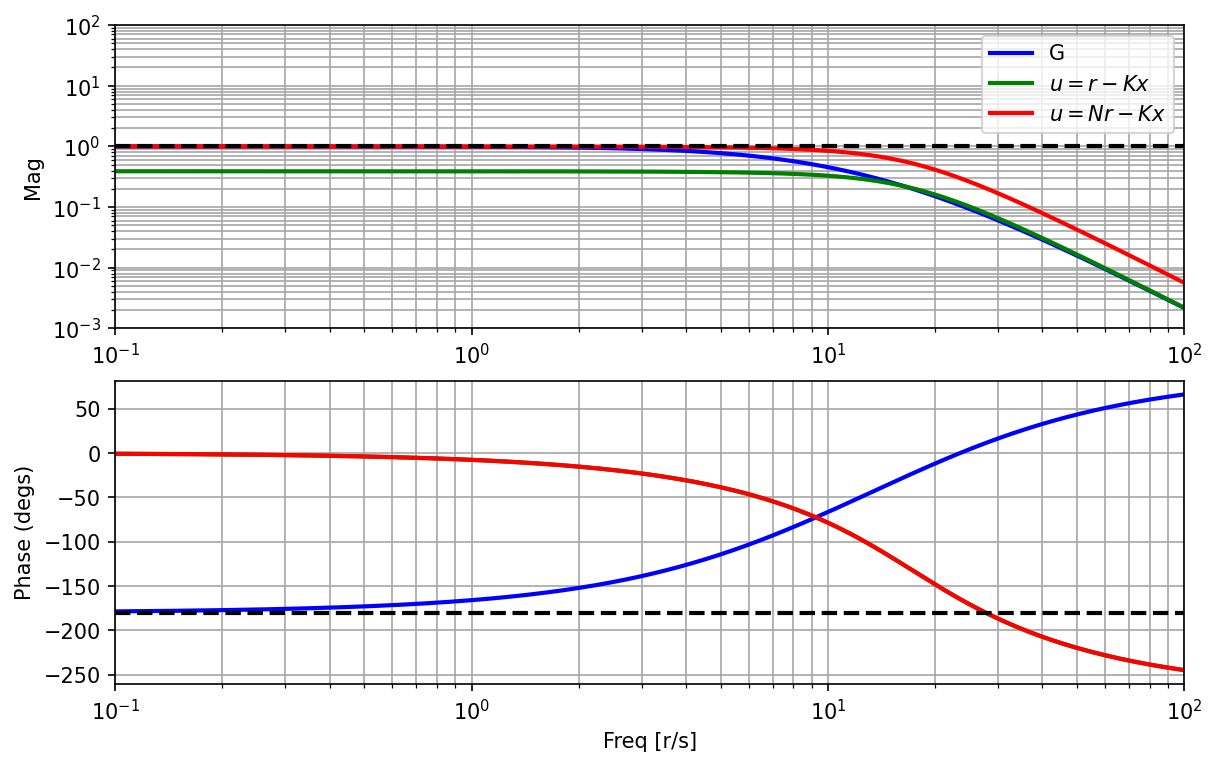

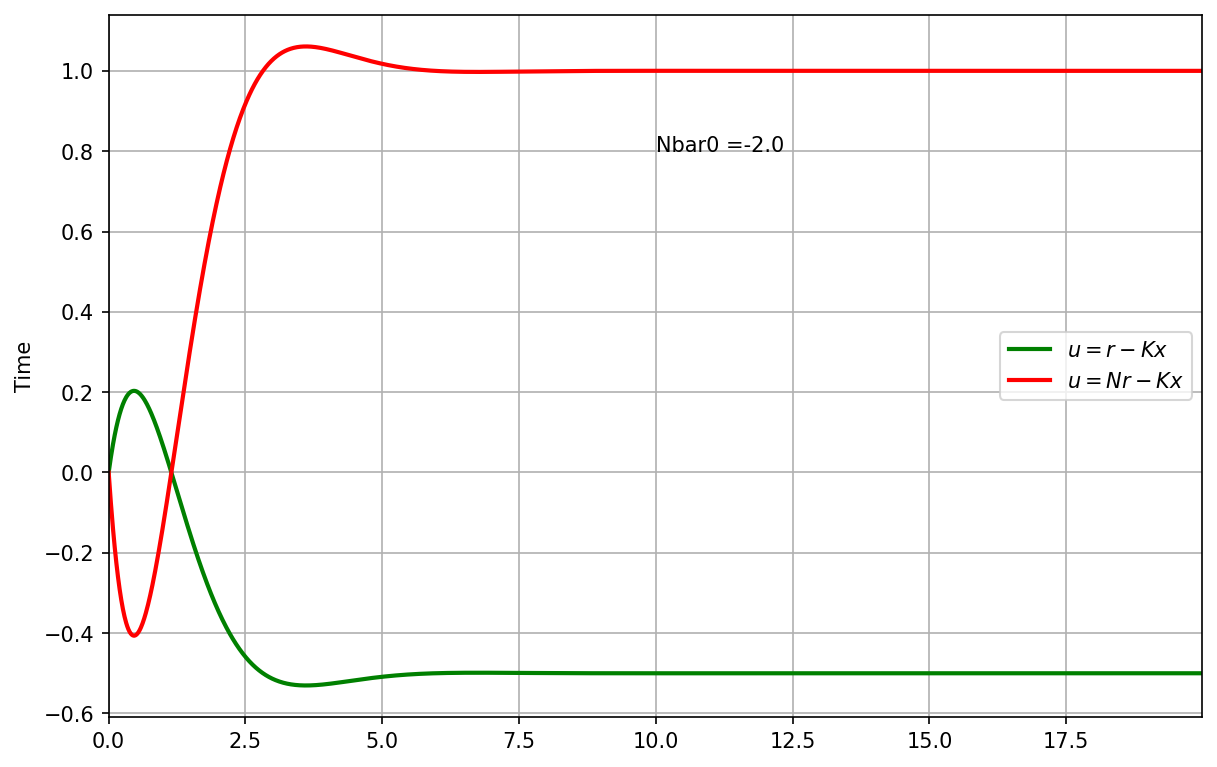

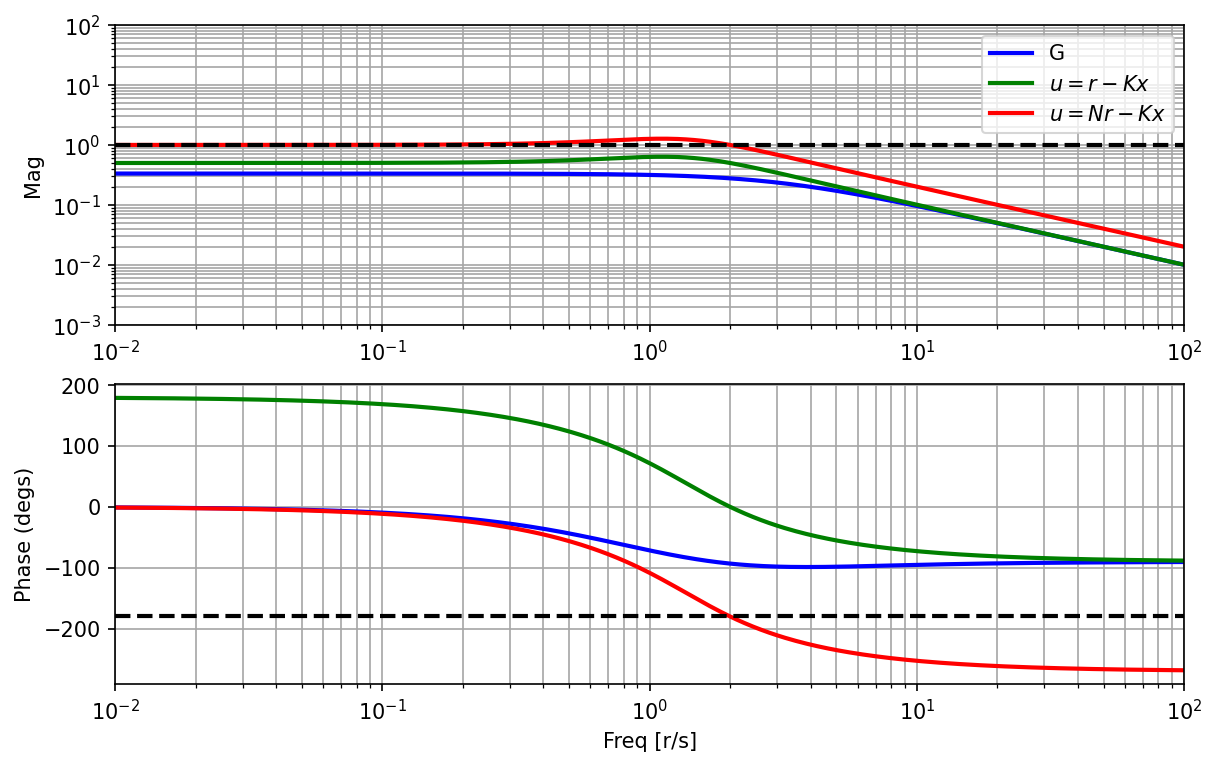

In [4]:
G1 = ss(tf(8*14*20,np.convolve([1, 8],np.convolve([1, 14],[1, 20]))))
pr = np.array([-20,-12+12*j,-12-12*j])
file_name = 'examp1'
K1 = FSFB_place(G1,pr,file_name=file_name)

G2 = ss(tf(0.94,(1,0,-0.0297)))
pr = np.array([-0.25+0.25*j,-0.25-0.25*j])
file_name = 'examp2'
K2 = FSFB_place(G2,pr,file_name=file_name,Tmax=20)

G3 = ss(tf(8*14*20,np.convolve([1, -8],np.convolve([1, -14],[1, -20]))))
pr = np.array([-20,-12+12*j,-12-12*j])
file_name = 'examp3'
K3 = FSFB_place(G3,pr,file_name=file_name)

G4 = ss(tf((1,-1),(1,-2,-3)))
pr = np.array([-1+j,-1-j])
file_name = 'examp4'
K4 = FSFB_place(G4,pr,file_name=file_name,Tmax=20)


## FSFB

In [5]:
def FSFB(G,R,file_name='temp',w=np.logspace(-1,2,400),Tmax=1):
    nx = G.A.shape[0]

    k0,_,_ = lqr(G.A,G.B,G.C.reshape(nx,1)*G.C,R)
    k0 = np.squeeze(np.asarray(k0))
    k1,_,_ = lqr(G.A,G.B,G.C.reshape(nx,1)*G.C,10*R)
    k1 = np.squeeze(np.asarray(k1))
    #
    # For state space for G_c(s)
    #
    # find the feedforward gains
    Nbar0 = float(np.linalg.inv(-G.C*np.linalg.inv(G.A-G.B*k0)*G.B))
    Nbar1 = float(np.linalg.inv(-G.C*np.linalg.inv(G.A-G.B*k1)*G.B))

    sys0 = ss(G.A-G.B*k0,G.B*Nbar0,G.C,G.D);
    sys1 = ss(G.A-G.B*k1,G.B*Nbar1,G.C,G.D);

    if nx < 4:
        w = np.logspace(0,3,400)
    else:
        w = np.logspace(-1,2,400)
    Gf = G(w*j)
    sys0f = sys0(j*w)
    sys1f = sys1(j*w)

    t = np.arange(0,Tmax,.01)    
    y0,t0 = step(sys0,T=t)
    y1,t1 = step(sys1,T=t)

    fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax.plot(t0,y0,'b-',label=r'$y_0$'+f" {R =:5.3f}")
    ax.plot(t1,y1,'g--',label=r'$y_1$'+f" {10*R =:5.3f}")
    plt.legend()
    plt.text(max(t0)/2,.8,f"{Nbar0 =:3.1f}")
    if nx < 4:
        plt.text(max(t0)/2,.5,['{:6.3f}'.format(x) for x in k0])
    plt.ylabel("Response")
    plt.ylabel("Time")
    savefig("figs/FSFB"+file_name+"_0.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(sys0f),'g',label=r'sys0'+f" {R =:5.3f}")
    ax[1].semilogx(w,np.unwrap(np.angle(sys0f))*r2d,'g',label=r'sys0'+f" {R =:5.3f}")
    ax[0].loglog(w,np.abs(sys1f),'r',label=r'sys1'+f" {10*R =:5.3f}")
    ax[1].semilogx(w,np.unwrap(np.angle(sys1f))*r2d,'r',label=r'sys1'+f" {10*R =:5.3f}")

    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    ax[1].axhline(y=-180,c='k',ls='--')
    ax[0].legend()
    ax[0].set_ylim(1e-3,100)
    savefig("figs/FSFB"+file_name+"_1.pdf", dpi=600)
    plt.show()

    return k0

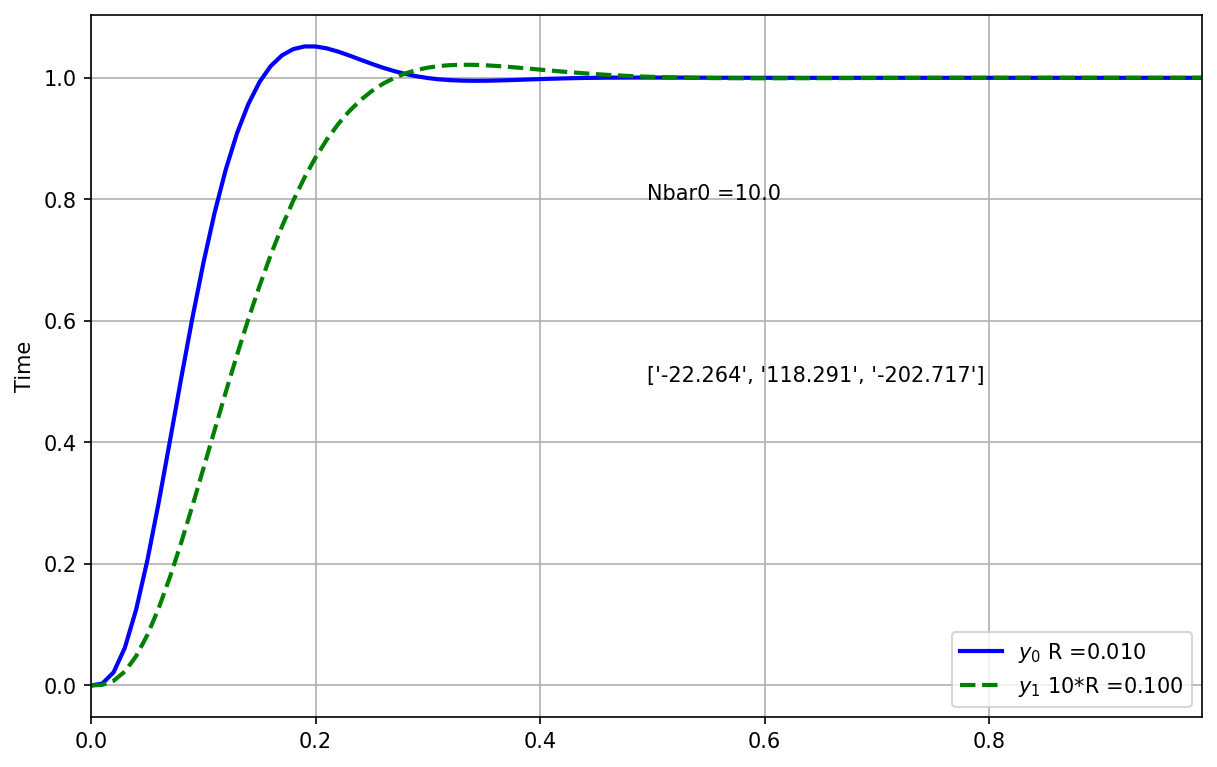

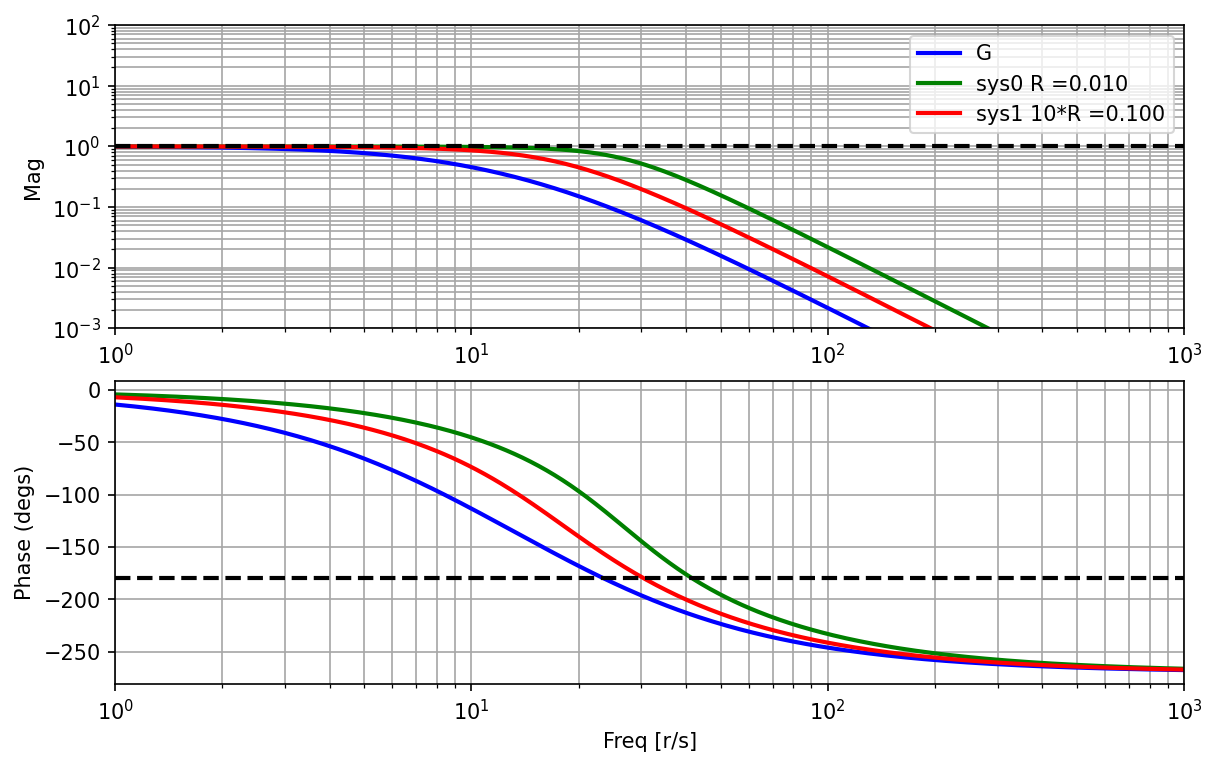

In [6]:
G1 = ss(tf(8*14*20,np.convolve([1, 8],np.convolve([1, 14],[1, 20]))))
R = 1e-2
file_name = 'examp1'
K1 = FSFB(G1,R,file_name=file_name)

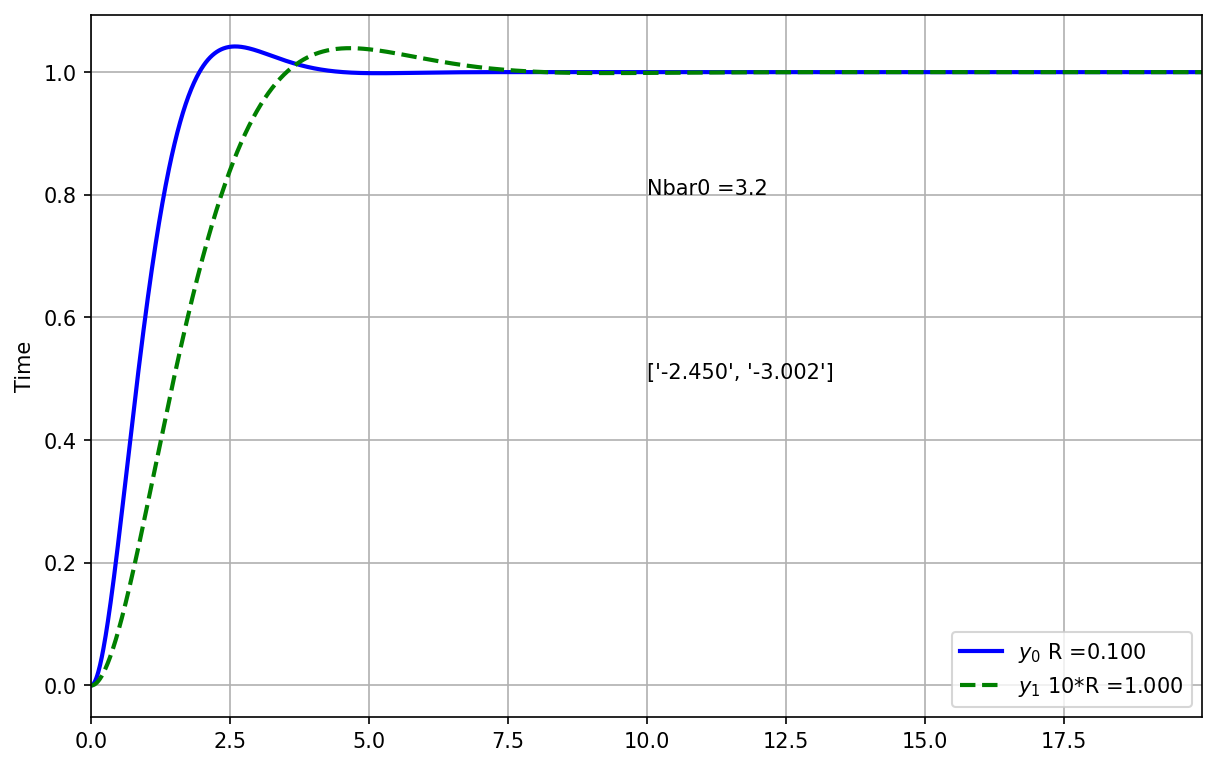

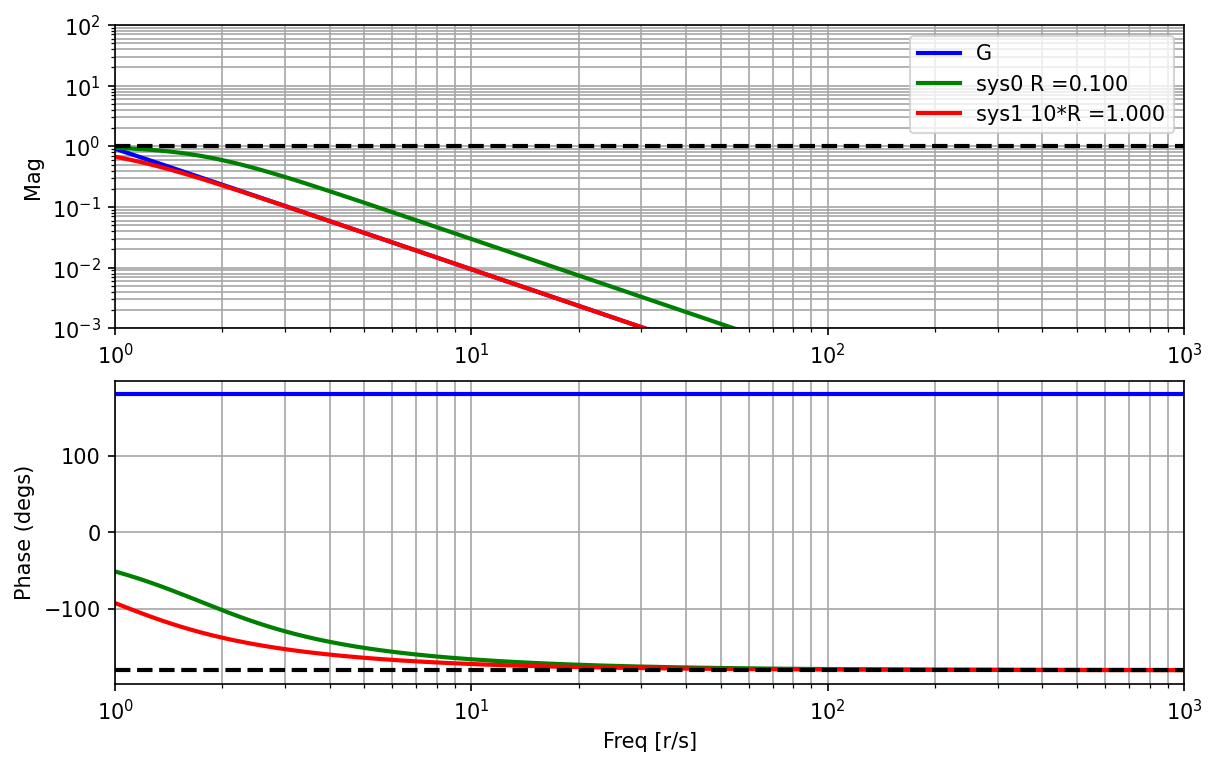

In [7]:
G2 = ss(tf(0.94,(1,0,-0.0297)))
R = 0.1
file_name = 'examp2'
K2 = FSFB(G2,R,file_name=file_name,Tmax=20)

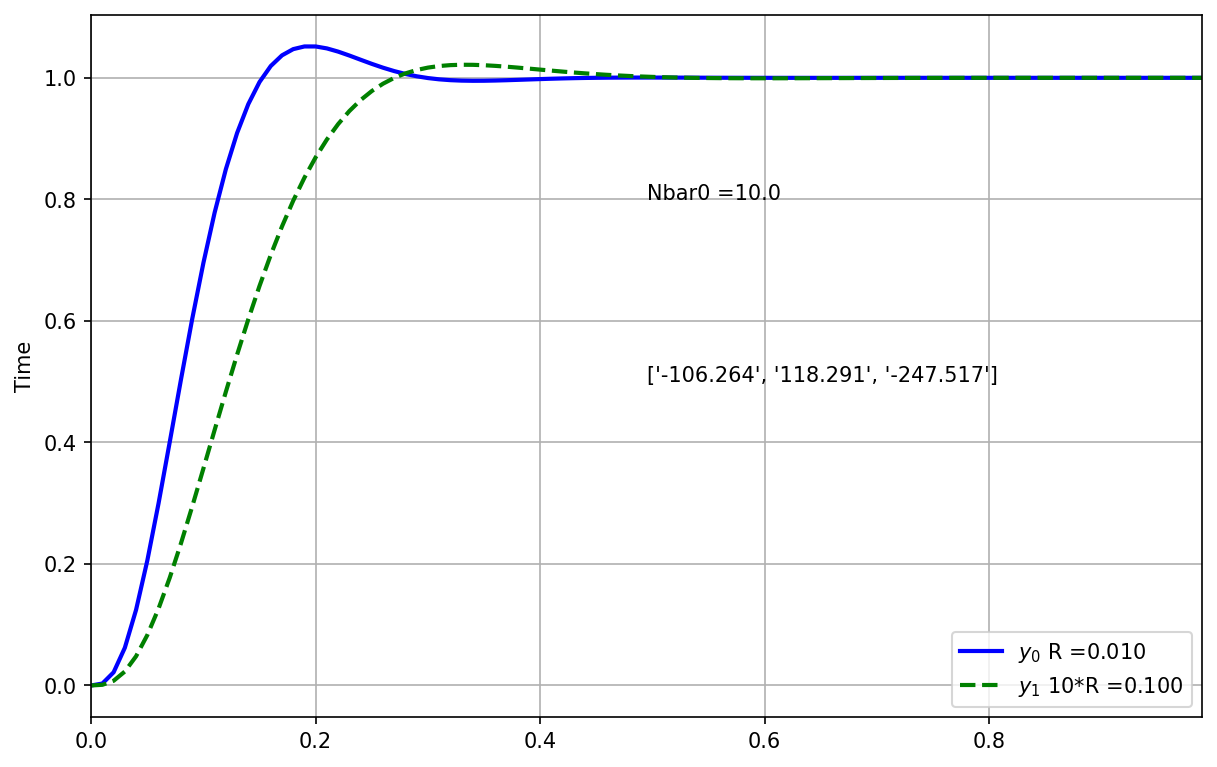

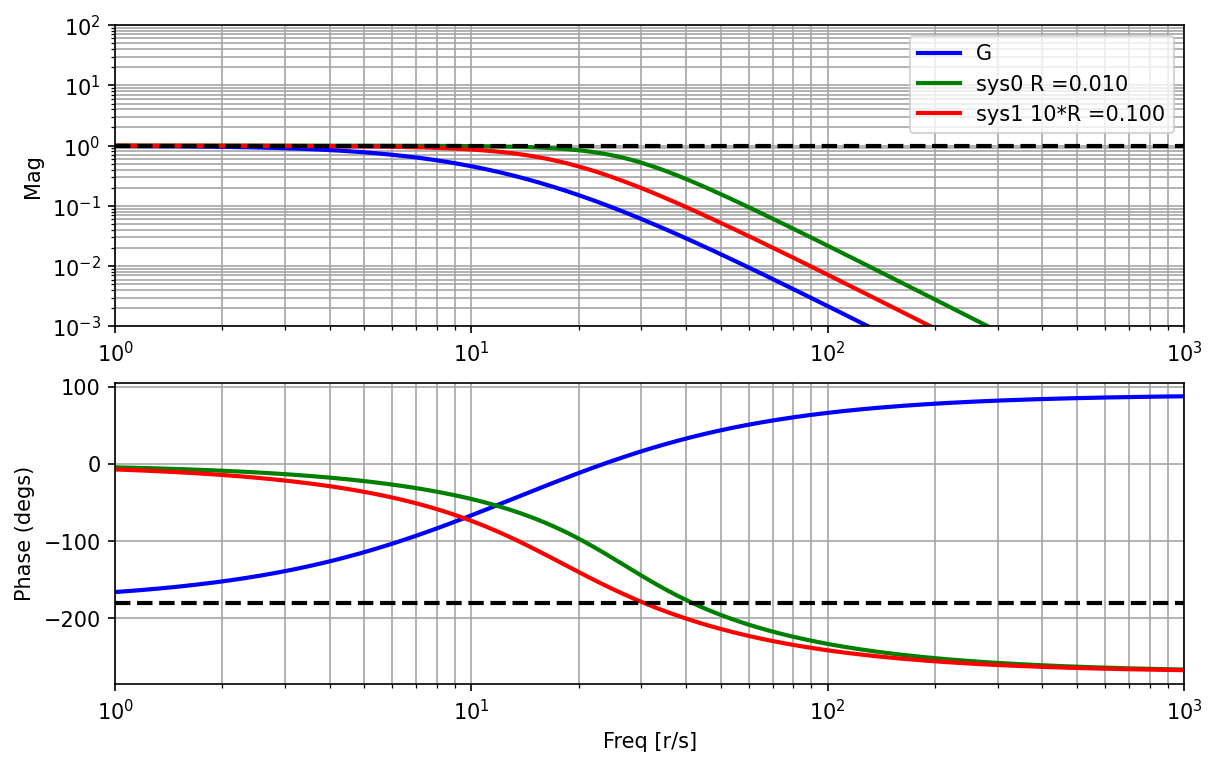

In [8]:
G3 = ss(tf(8*14*20,np.convolve([1, -8],np.convolve([1, -14],[1, -20]))))
R = 1e-2
file_name = 'examp3'
K3 = FSFB(G3,R,file_name=file_name)


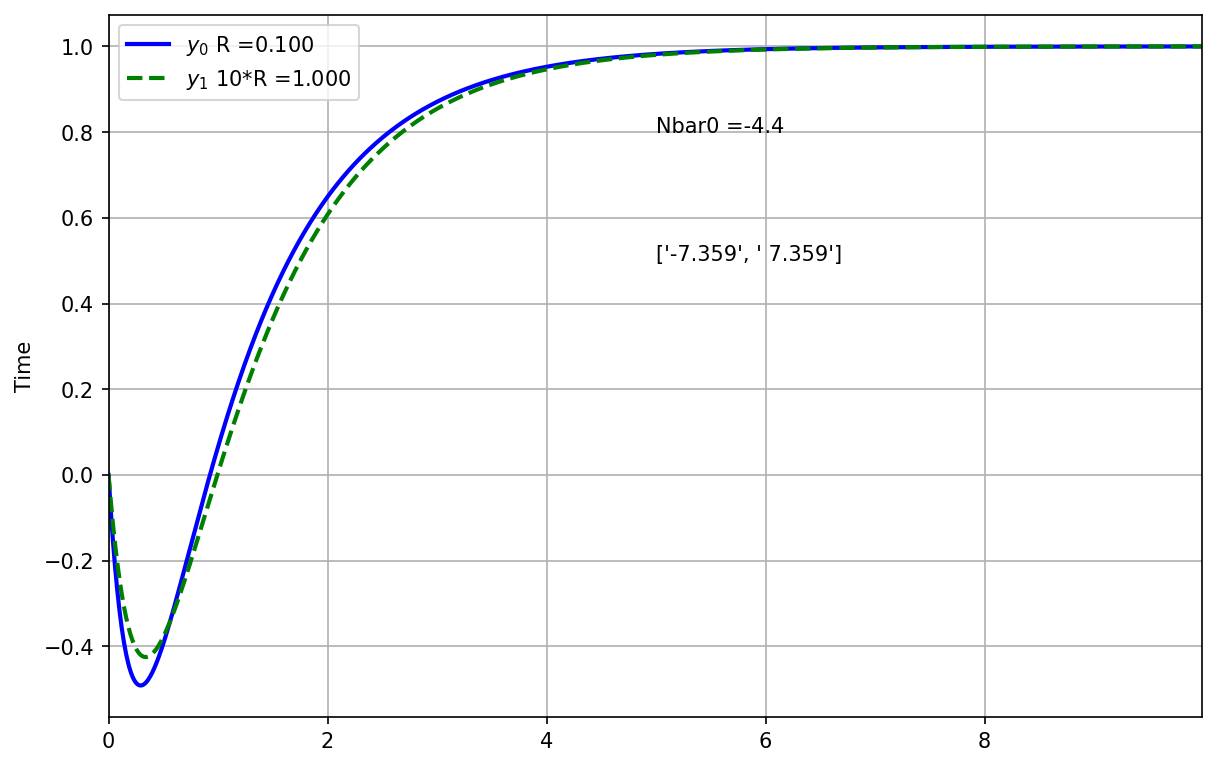

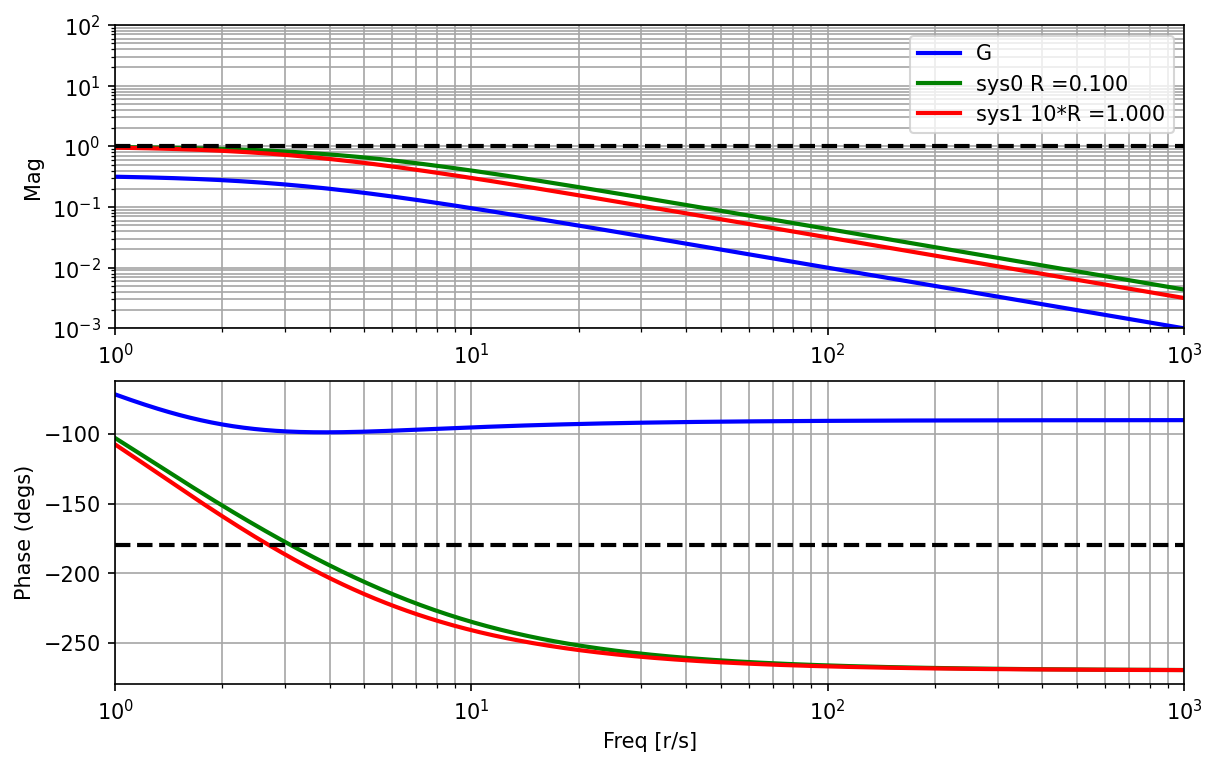

In [9]:
G4 = ss(tf((1,-1),(1,-2,-3)))
R = 0.1
file_name = 'examp4'
K4 = FSFB(G4,R,file_name=file_name,Tmax=10)

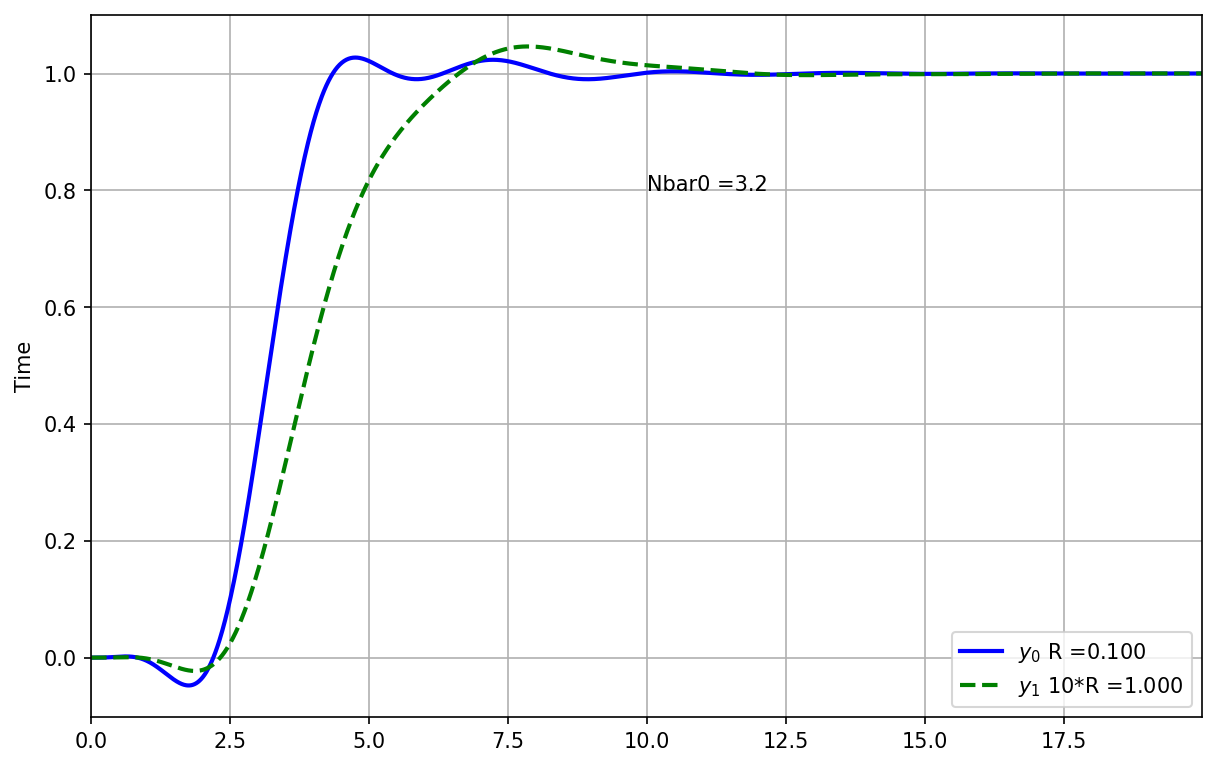

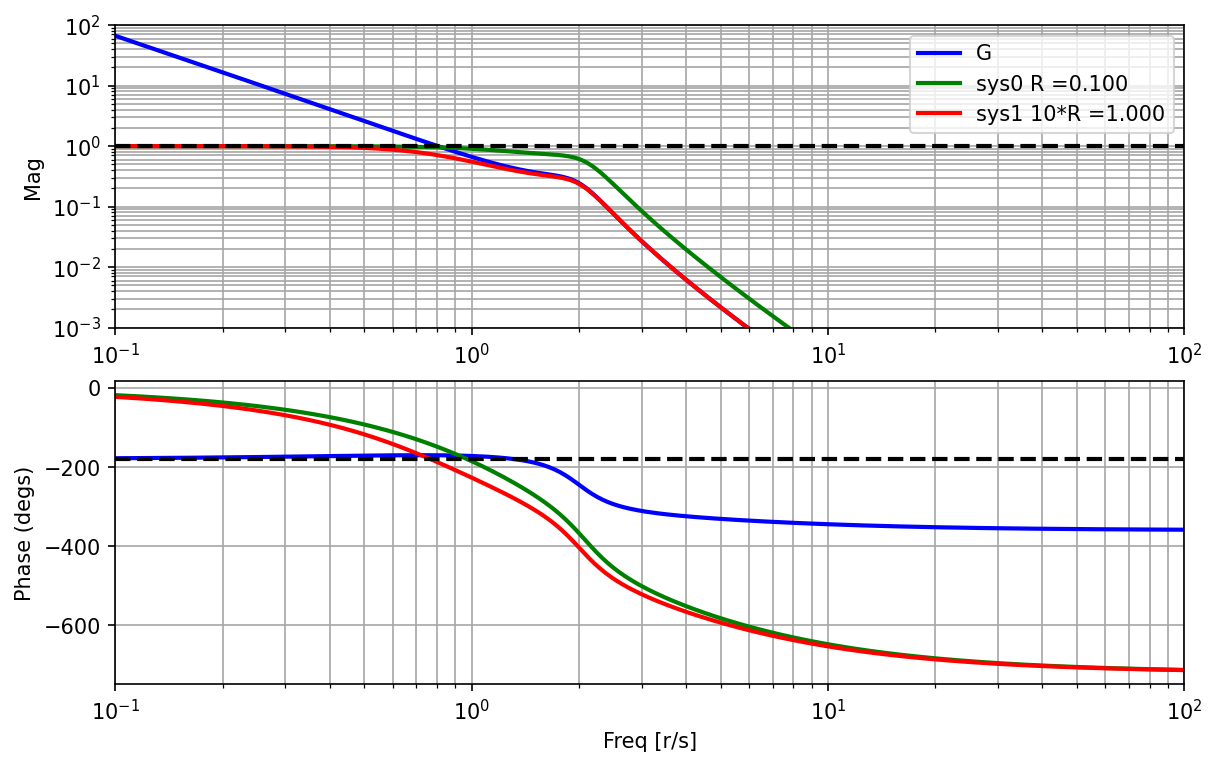

In [10]:
G5 = ss(tf((1,-6,8),np.convolve([1,0,0],np.convolve([1,.8,4],[1,-4,3]))))
R = 0.1
file_name = 'examp5'
K5 = FSFB(G5,R,file_name=file_name,Tmax=20)

## Estimator Performance

In [11]:
from control.matlab import place
a = np.array([[-1, 1.5],[1, -2]])
nx = a.shape[0]
b = np.array([1,0]).reshape(nx,1);
c = np.array([1, 0])
d = 0

pe = np.array([-3, -4])
G = ss(a,b,c,d)
l = place(G.A.transpose(),G.C.reshape(nx,1),pe)
l = l.reshape(nx,1)

x0 = np.array([-0.5,-1]).reshape(nx,1);
xe = np.array([0,0]).reshape(nx,1);
X0 = np.vstack((x0, xe ))

t = np.arange(0,4,.01)

# input
Nwidth = min(np.argwhere(t>1.5))[0]
u = 0*t
u [0:Nwidth] = 1
u [Nwidth:2*Nwidth] = -1
u [3*Nwidth:4*Nwidth] = 1/2
u [4*Nwidth:5*Nwidth] = -1/2

#OL est
aol = np.vstack((np.hstack((G.A,np.zeros((nx,nx)))),np.hstack((np.zeros((nx,nx)),G.A))))
bol = np.vstack((G.B, G.B ))
col = np.hstack((G.C.reshape(1,nx), G.C.reshape(1,nx) ))
dol = 0
Gest_ol = ss(aol,bol,col,dol)

#CL est
acl = np.vstack((np.hstack((G.A,np.zeros((nx,nx)))),np.hstack((l*G.C,G.A - l*G.C))))
bcl = np.vstack((G.B, G.B ))
ccl = np.hstack((G.C.reshape(1,nx), G.C.reshape(1,nx) ))
dcl = 0
Gest_cl = ss(acl,bcl,ccl,dcl)

from control.matlab import lsim
y_cl,t_cl,x_cl = lsim(Gest_cl,U=u,T=t,X0=X0)
y_ol,t_ol,x_ol = lsim(Gest_ol,U=u,T=t,X0=X0)


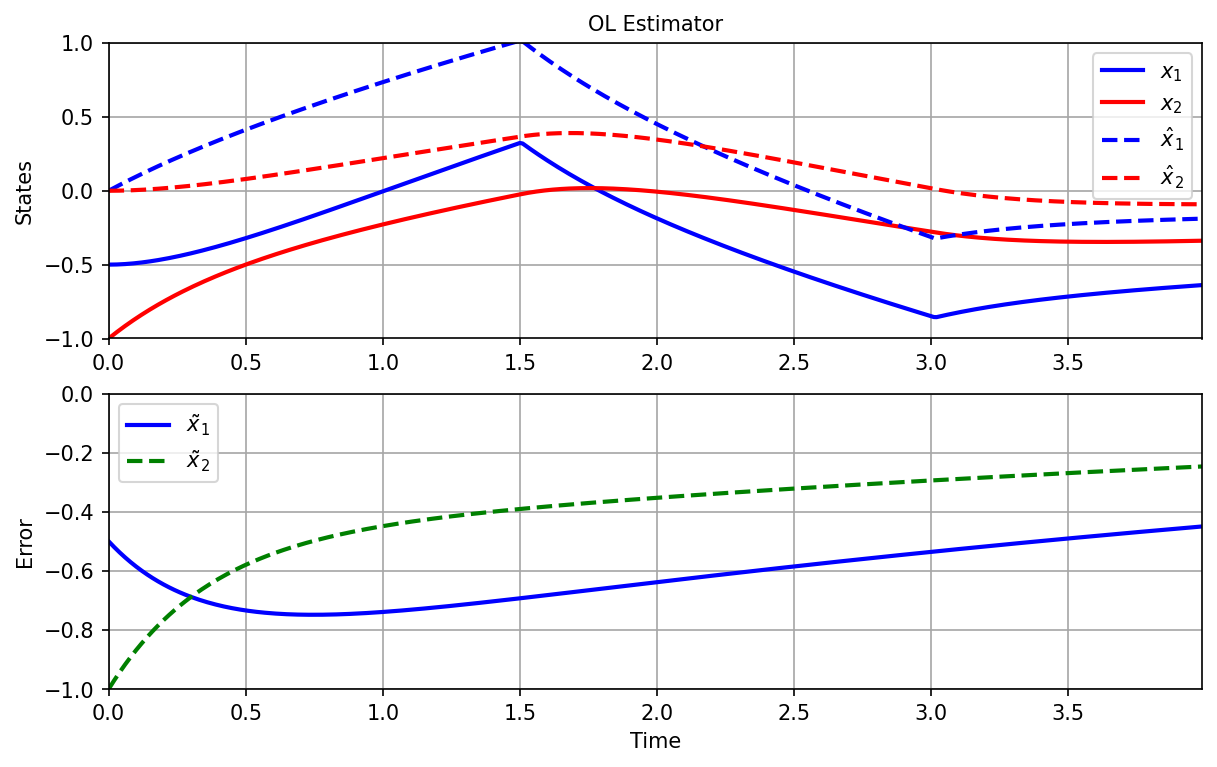

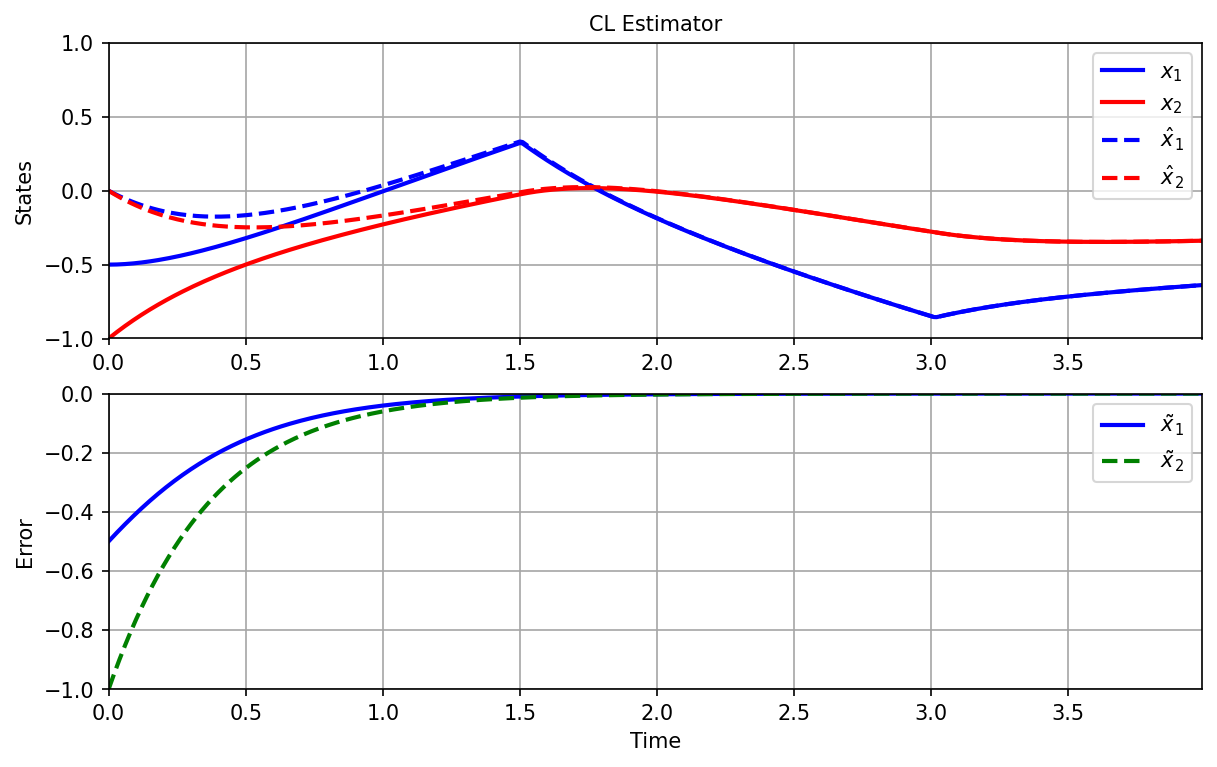

In [12]:
fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].plot(t_ol,x_ol[:,0],'b',label=r'$x_1$')
ax[0].plot(t_ol,x_ol[:,1],'r-',label=r'$x_2$')
ax[0].plot(t_ol,x_ol[:,2],'b--',label=r'$\hat x_1$')
ax[0].plot(t_ol,x_ol[:,3],'r--',label=r'$\hat x_2$')
ax[1].plot(t_ol,x_ol[:,0]-x_ol[:,2],'b',label=r'$\tilde x_1$')
ax[1].plot(t_ol,x_ol[:,1]-x_ol[:,3],'g--',label=r'$\tilde x_2$')
ax[1].set_xlabel('Time')
ax[0].set_ylabel('States')
ax[1].set_ylabel('Error')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
#ax[0].axhline(y=1,c='k',ls='--')
#ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[1].legend()
ax[0].set_ylim(-1,1)
ax[1].set_ylim(-1,0)
ax[0].set_title("OL Estimator")
savefig("figs/Est_1.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].plot(t_cl,x_cl[:,0],'b',label=r'$x_1$')
ax[0].plot(t_cl,x_cl[:,1],'r-',label=r'$x_2$')
ax[0].plot(t_cl,x_cl[:,2],'b--',label=r'$\hat x_1$')
ax[0].plot(t_cl,x_cl[:,3],'r--',label=r'$\hat x_2$')
ax[1].plot(t_cl,x_cl[:,0]-x_cl[:,2],'b',label=r'$\tilde x_1$')
ax[1].plot(t_cl,x_cl[:,1]-x_cl[:,3],'g--',label=r'$\tilde x_2$')
ax[1].set_xlabel('Time')
ax[0].set_ylabel('States')
ax[1].set_ylabel('Error')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
#ax[0].axhline(y=1,c='k',ls='--')
#ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[1].legend()
ax[0].set_ylim(-1,1)
ax[1].set_ylim(-1,0)
ax[0].set_title("CL Estimator")
savefig("figs/Est_2.pdf", dpi=600)
plt.show()

## DOFB

In [13]:
a = np.array([[0, 1],[-1, -1]])
nx = np.shape(a)[0]
b = np.array([0, 1]).reshape(nx,1)
c = np.array([1, 0])
d = 0

j = complex(0,1)
pr = np.array([-4+4*j, -4-4*j])
pe = np.array([-10, -11])

k = place(a,b,pr);
l = place(a.transpose(),c.reshape(nx,1),pe)
l = l.reshape(nx,1)
#
# For state space for G_c(s)
#
ac = a-b@k-l*c
bc = l
cc = k
dc = 0


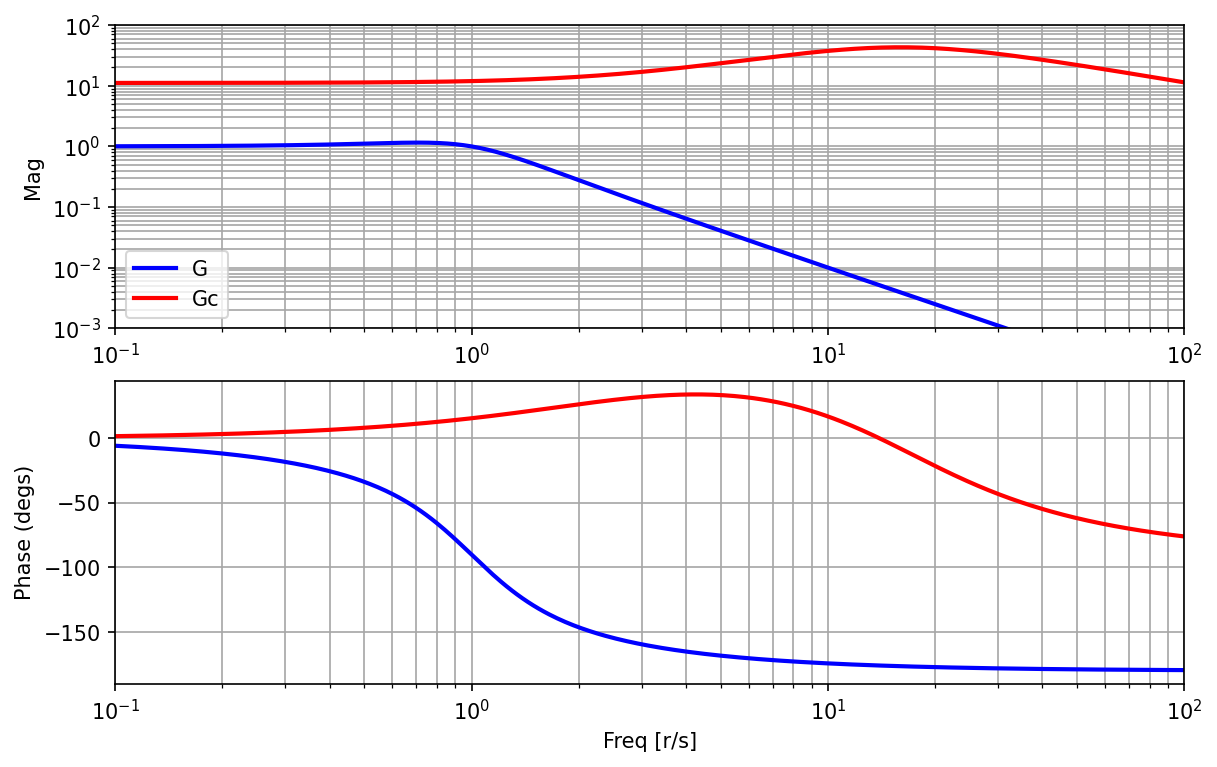

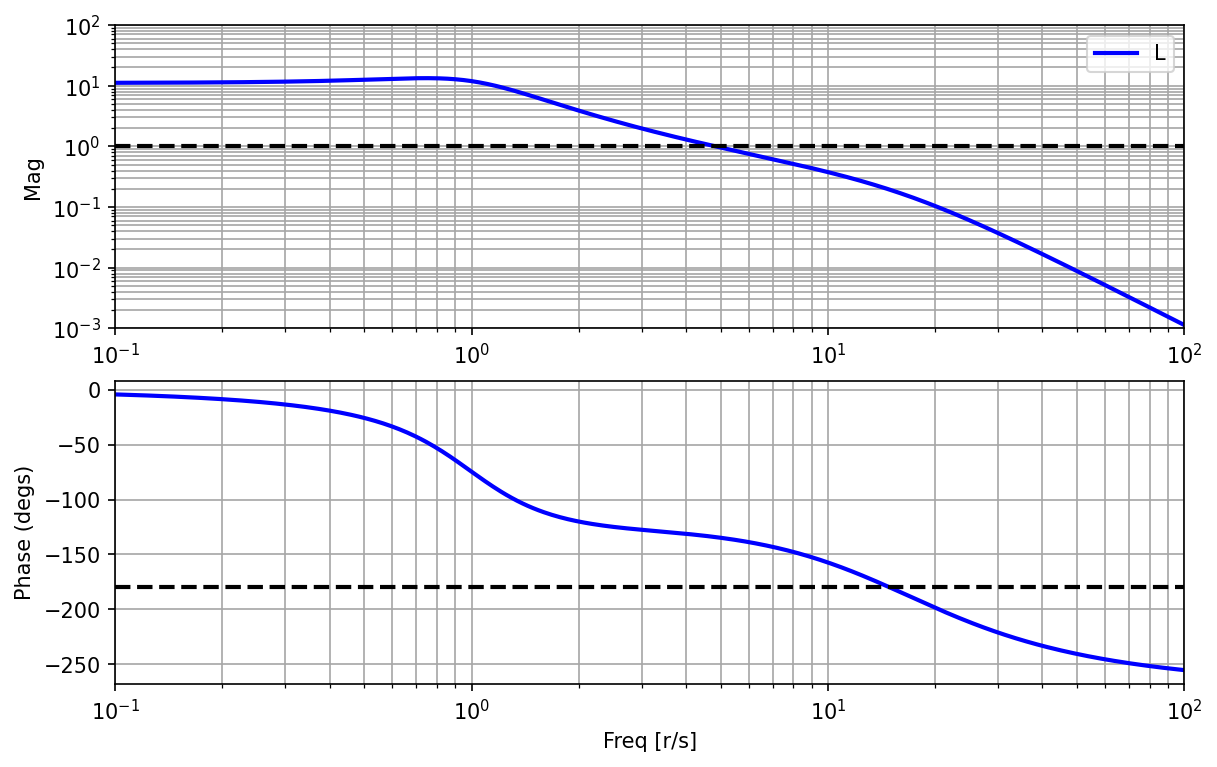

In [14]:
# Combined estimator/regulator design for a simple system
# G= 1/(s^2+s+1)
# Jonathan How
a = np.array([[0, 1],[-1, -1]])
nx = np.shape(a)[0]
b = np.array([0, 1]).reshape(nx,1)
c = np.array([1, 0])
d = 0

j = complex(0,1)
pr = np.array([-4+4*j, -4-4*j])
pe = np.array([-10.001, -10])

k = place(a,b,pr);
l = place(a.transpose(),c.reshape(nx,1),pe)
l = l.reshape(nx,1)
#
# For state space for G_c(s)
#
ac = a-b*k-l*c
bc = l
cc = k
dc = 0

G = ss(a,b,c,d);
Gc = ss(ac,bc,cc,dc)
L = G*Gc

w = np.logspace(-1,2,400)
Gf = G(w*j)
Gcf = Gc(j*w)
Lf = L(j*w)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gcf),'r',label=r'Gc')
ax[1].semilogx(w,np.unwrap(np.angle(Gcf))*r2d,'r',label=r'Gc')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB0.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Lf),'b',label=r'L')
ax[1].semilogx(w,np.unwrap(np.angle(Lf))*r2d,'b',label=r'L')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].axhline(y=1,c='k',ls='--')
ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB1.pdf", dpi=600)
plt.show()


Found breakin/out at K = 1.000
At possible locations s = -10.001


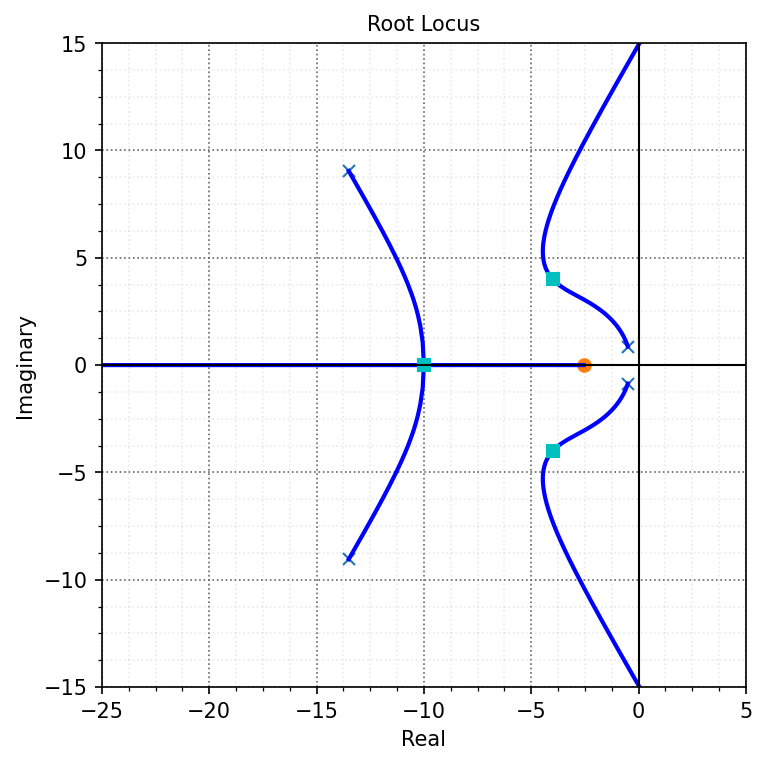

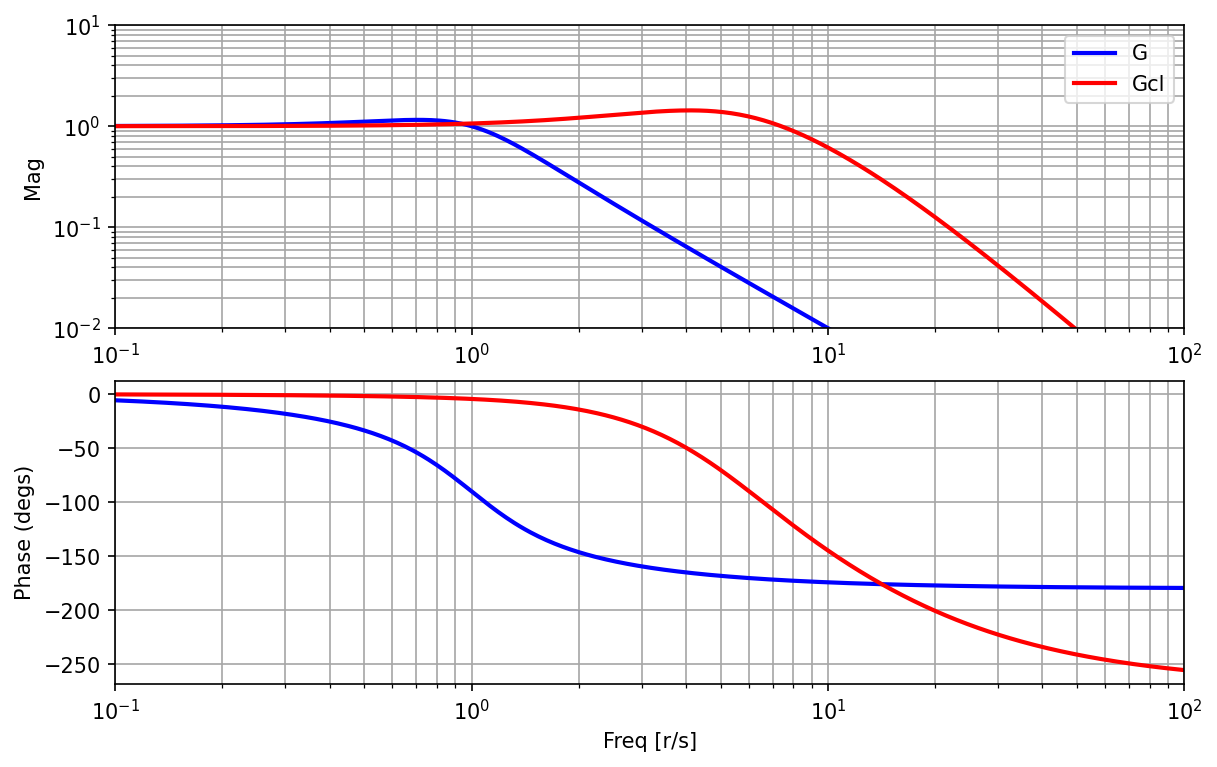

In [15]:
#
# loop dynamics L = G Gc
#
al = np.vstack((np.hstack((a,b*cc)),np.hstack((np.zeros((nx,nx)),ac))))
bl = np.vstack((np.zeros((nx,1)), bc ))
cl = np.hstack((c.reshape(1,nx), np.zeros((1,nx)) ))
dl = 0
L = ss2tf(al,bl,cl,dl)
#
# closed-loop dynamics
# unity gain wrapped around loop L
#
acl = al - bl*cl
bcl = bl 
ccl = cl
dcl = d
# scale closed-loop to get zero SS error
N = np.linalg.inv(ccl*np.linalg.inv(-acl)*bcl)
Gcl = ss2tf(acl,bcl*N,ccl,dcl*N)
scl = Gcl.poles()
Gclf = Gcl(j*w)

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rlist, klist = rlocus(L, kvect=Root_Locus_gains(L), plotstr='b-', grid=False,ax=ax)
plt.plot(np.real(scl),np.imag(scl),'cs')
ax.set_aspect('equal')
ax.set_xlim([-25, 5]);
ax.set_ylim([-15, 15])
nicegrid(ax)
savefig("figs/DOFB2.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gclf),'r',label=r'Gcl')
ax[1].semilogx(w,np.unwrap(np.angle(Gclf))*r2d,'r',label=r'Gcl')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-2,10)
savefig("figs/DOFB3.pdf", dpi=600)
plt.show()


In [16]:
def DOFB(G,pr,pe,file_name='temp',w=np.logspace(-1,2,400),use_y_lims=True):
    nx = G.A.shape[0]
    k = place(G.A,G.B,pr)
    l = place(G.A.transpose(),G.C.reshape(nx,1),pe)
    l = l.reshape(nx,1)
    #
    # For state space for G_c(s)
    #
    ac = G.A-G.B*k-l*G.C
    bc = l
    cc = k
    dc = 0
    Gc = ss(ac,bc,cc,dc)
    L = G*Gc

    Gf = G(w*j)
    Gcf = Gc(j*w)
    #
    # loop dynamics L = G Gc
    #
    al = np.vstack((np.hstack((G.A,G.B*cc)),np.hstack((np.zeros((nx,nx)),ac))))
    bl = np.vstack((np.zeros((nx,1)), bc ))
    cl = np.hstack((G.C.reshape(1,nx), np.zeros((1,nx)) ))
    dl = 0
    L = ss2tf(al,bl,cl,dl)
    Lf = L(j*w)
    #
    # closed-loop dynamics
    # unity gain wrapped around loop L
    #
    acl = al - bl*cl
    bcl = bl 
    ccl = cl
    dcl = d
    # scale closed-loop to get zero SS error
    N = np.linalg.inv(ccl*np.linalg.inv(-acl)*bcl)
    Gcl = ss2tf(acl,bcl*N,ccl,dcl*N)
    scl = Gcl.poles()
    Gclf = Gcl(j*w)
    
    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(Gcf),'r',label=r'Gc')
    ax[1].semilogx(w,np.unwrap(np.angle(Gcf))*r2d,'r',label=r'Gc')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend()
    if use_y_lims:
        ax[0].set_ylim(1e-3,100)
    savefig("figs/DOFB"+file_name+"_0.pdf", dpi=600)
    plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Lf),'b',label=r'L')
    ax[1].semilogx(w,pshift(np.unwrap(np.angle(Lf)))*r2d,'b',label=r'L')
    test_val = np.mean(pshift(np.unwrap(np.angle(Lf)))*r2d)
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].axhline(y=1,c='k',ls='--')
    if test_val < 0:
        ax[1].axhline(y=-180,c='k',ls='--')
    else:
        ax[1].axhline(y=180,c='k',ls='--')
    ax[0].legend()
    if use_y_lims:
        ax[0].set_ylim(1e-3,100)
    savefig("figs/DOFB"+file_name+"_1.pdf", dpi=600)
    plt.show()

    if 0:
        fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
        rlist, klist = rlocus(L, kvect=Root_Locus_gains(L), plotstr='b-', grid=False,ax=ax)
        plt.plot(np.real(scl),np.imag(scl),'cs')
        ax.set_aspect('equal')
        ax.set_xlim([-25, 5]);
        ax.set_ylim([-15, 15])
        nicegrid(ax)
        savefig("figs/DOFB"+file_name+"_2.pdf", dpi=600)
        plt.show()

    fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
    ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
    ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
    ax[0].loglog(w,np.abs(Gclf),'r',label=r'Gcl')
    ax[1].semilogx(w,np.unwrap(np.angle(Gclf))*r2d,'r',label=r'Gcl')
    ax[1].set_xlabel('Freq [r/s]')
    ax[0].set_ylabel('Mag')
    ax[1].set_ylabel('Phase (degs)')
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend()
    ax[0].set_ylim(1e-2,10)
    savefig("figs/DOFB"+file_name+"_3.pdf", dpi=600)
    plt.show()
    
    return Gc,Gcl

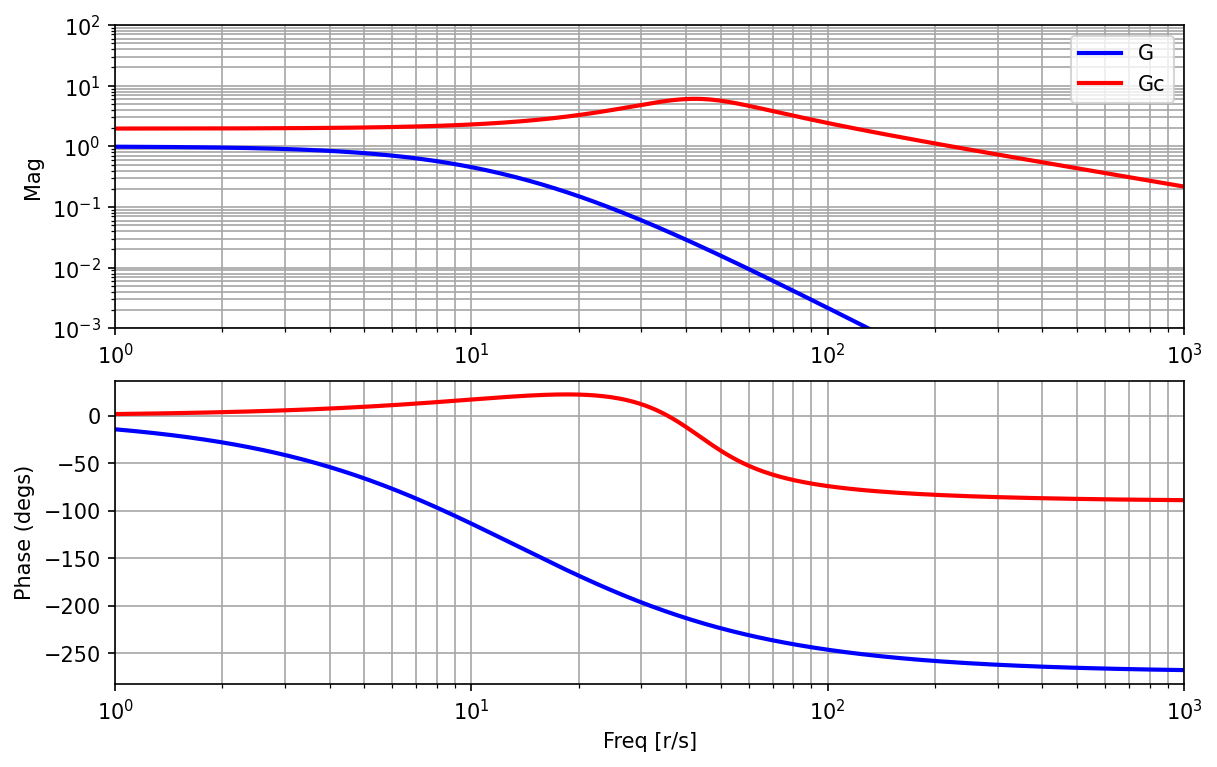

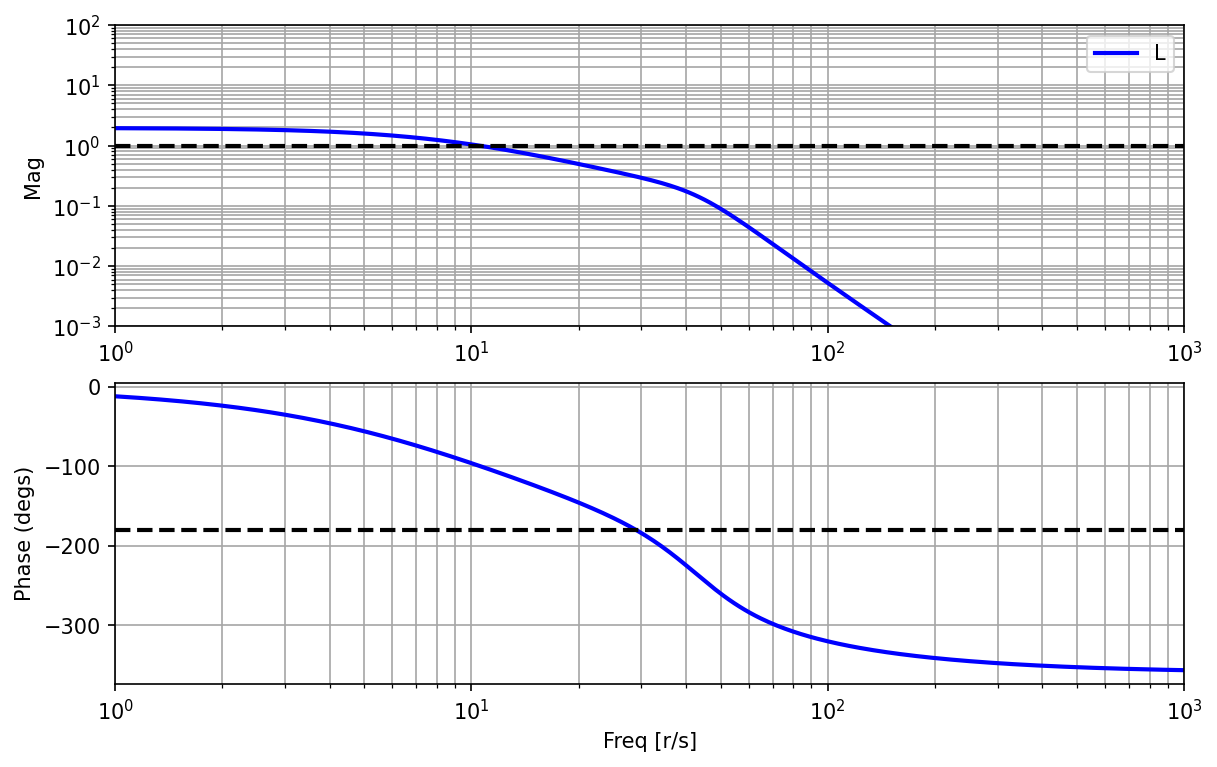

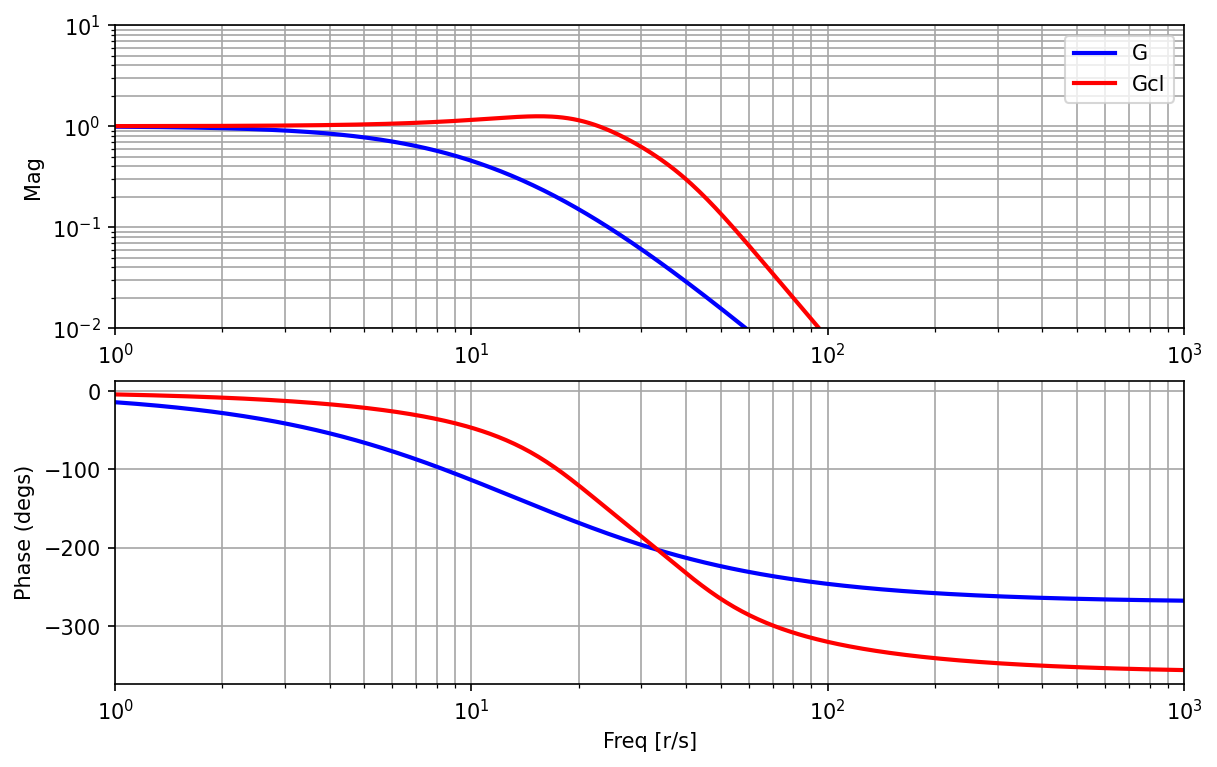

array([-40. +0.j        , -20.+34.64101615j, -20.-34.64101615j,
       -10.+17.32050808j, -10.-17.32050808j])

In [17]:
G1 = ss(tf(8*14*20,np.convolve([1, 8],np.convolve([1, 14],[1, 20]))))
file_name = 'examp1'
nx = len(G1.poles())
zz,pp,kk = butter(nx,20,output='zpk',analog=True)
pe = [2*p for p in pp]
Gc1,Gcl1 = DOFB(G1,pp,pe,file_name=file_name, w=np.logspace(0,3,400))
Gcl1.poles()

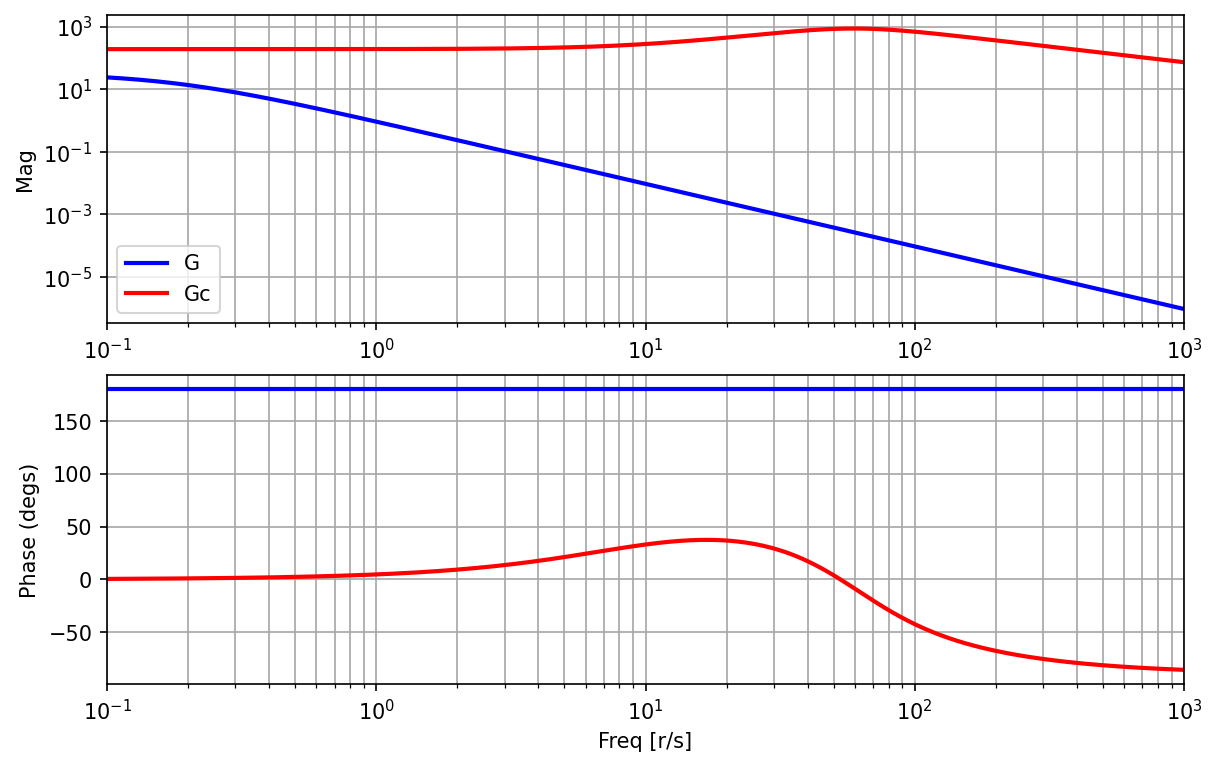

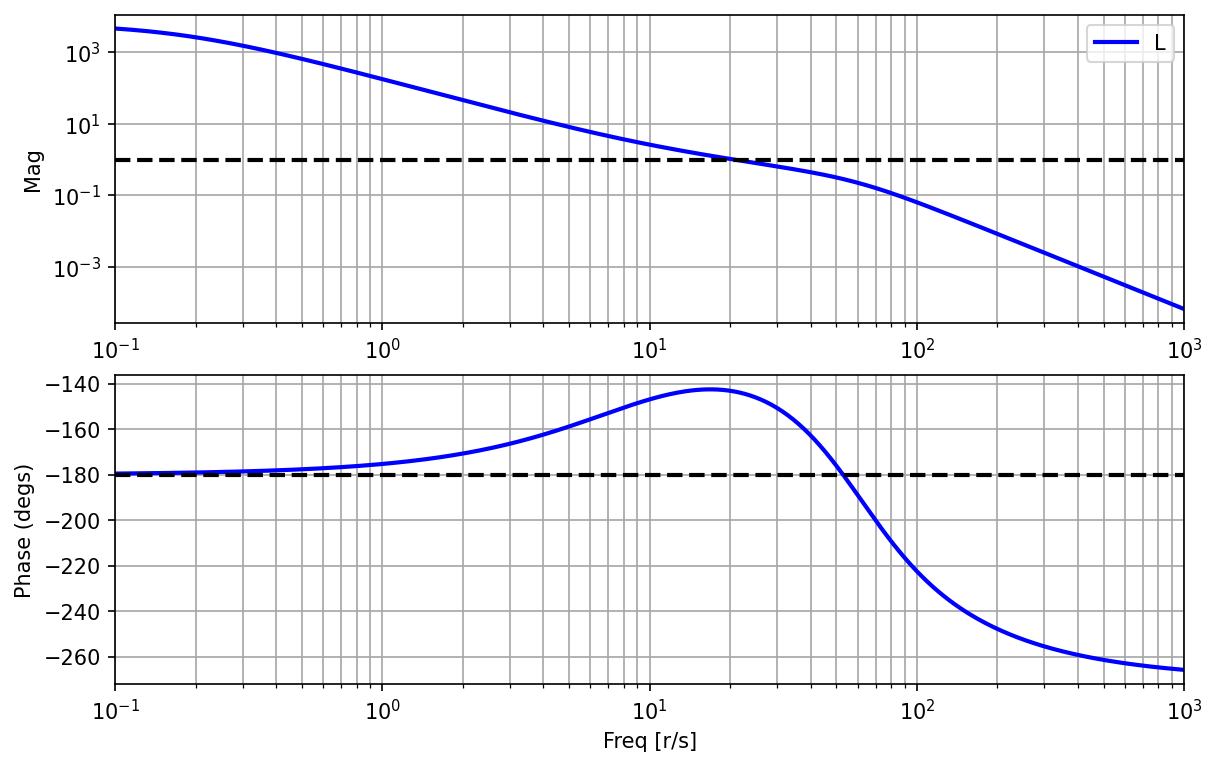

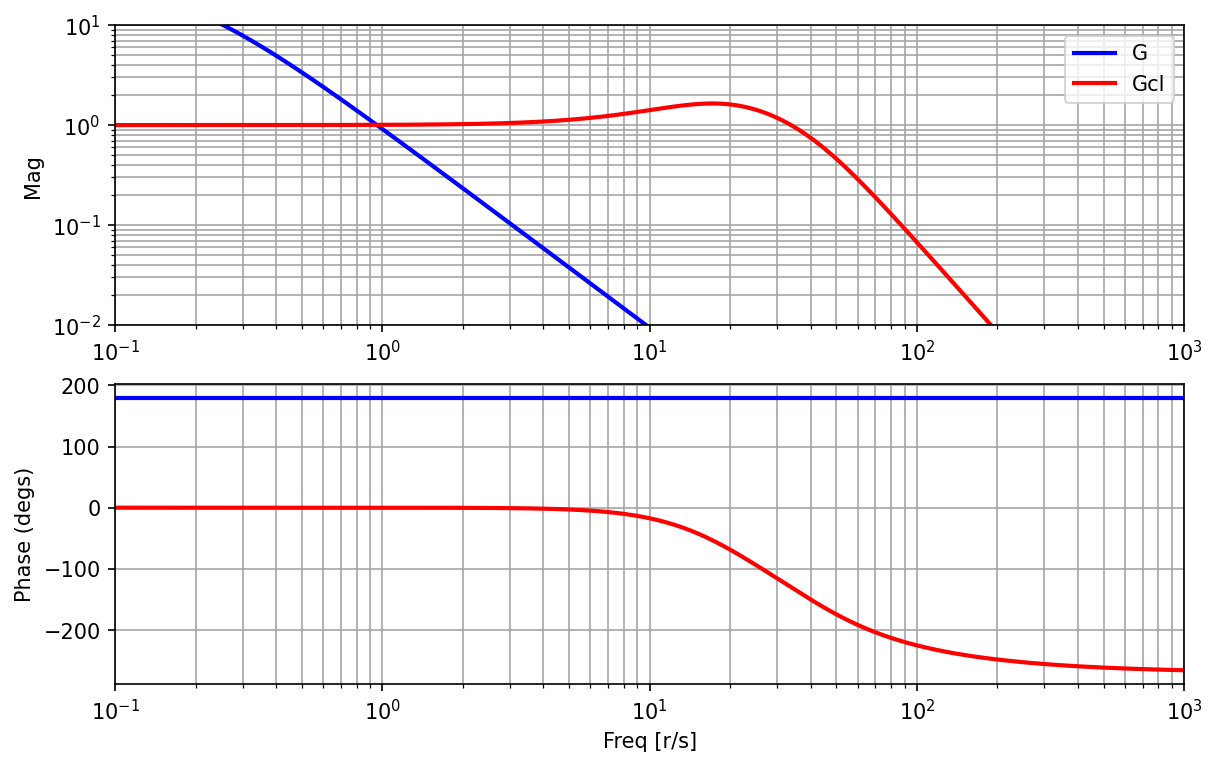

array([-28.28427125+28.28427125j, -28.28427125-28.28427125j,
       -14.14213562+14.14213562j, -14.14213562-14.14213562j])

In [18]:
G2 = ss(tf(0.94,(1,0,-0.0297)))
file_name = 'examp2'
nx = len(G2.poles())
zz,pp,kk = butter(nx,20,output='zpk',analog=True)
pe = [2*p for p in pp]
Gc2,Gcl2 = DOFB(G2,pp,pe,file_name=file_name, w=np.logspace(-1,3,400),use_y_lims=False)
Gcl2.poles()

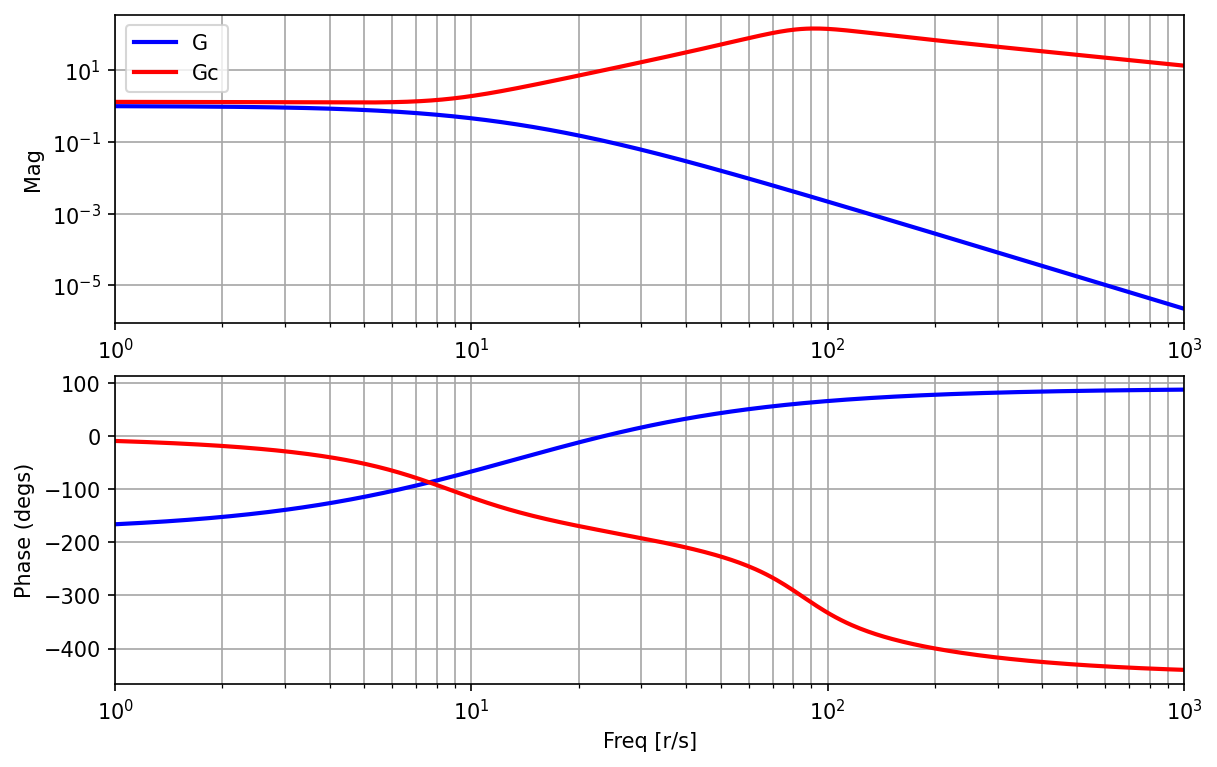

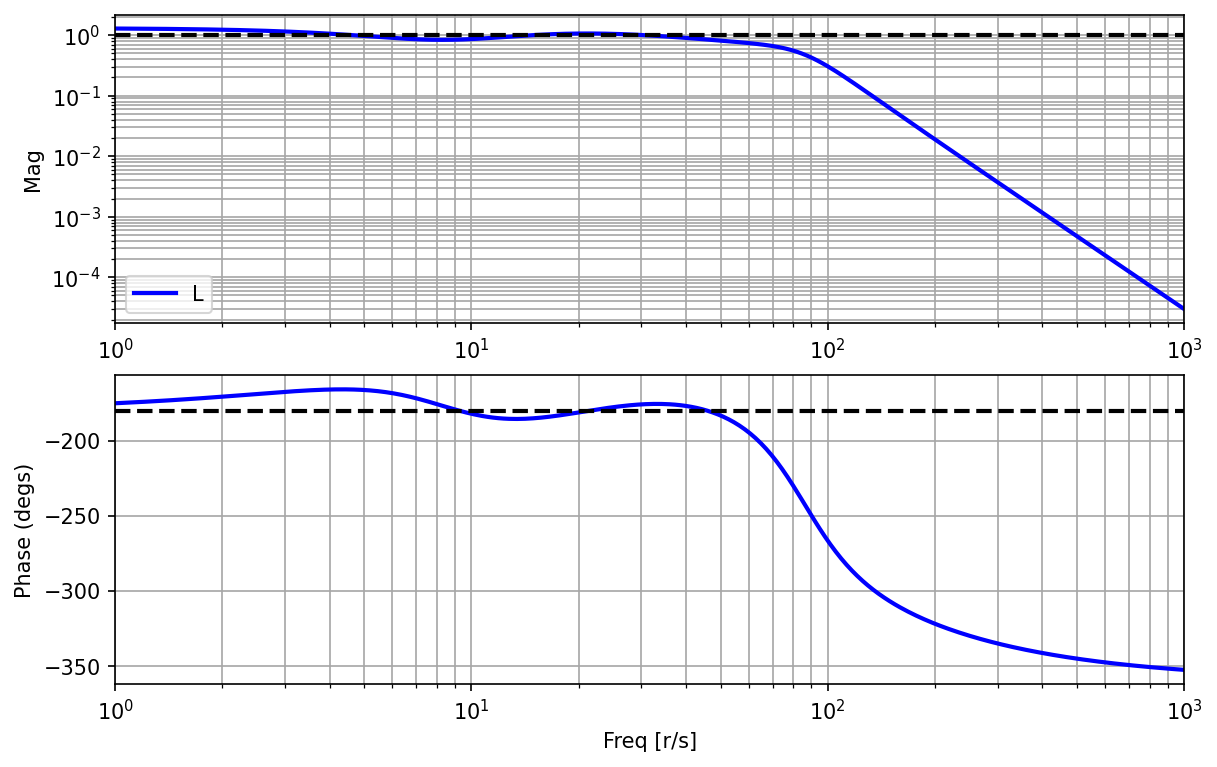

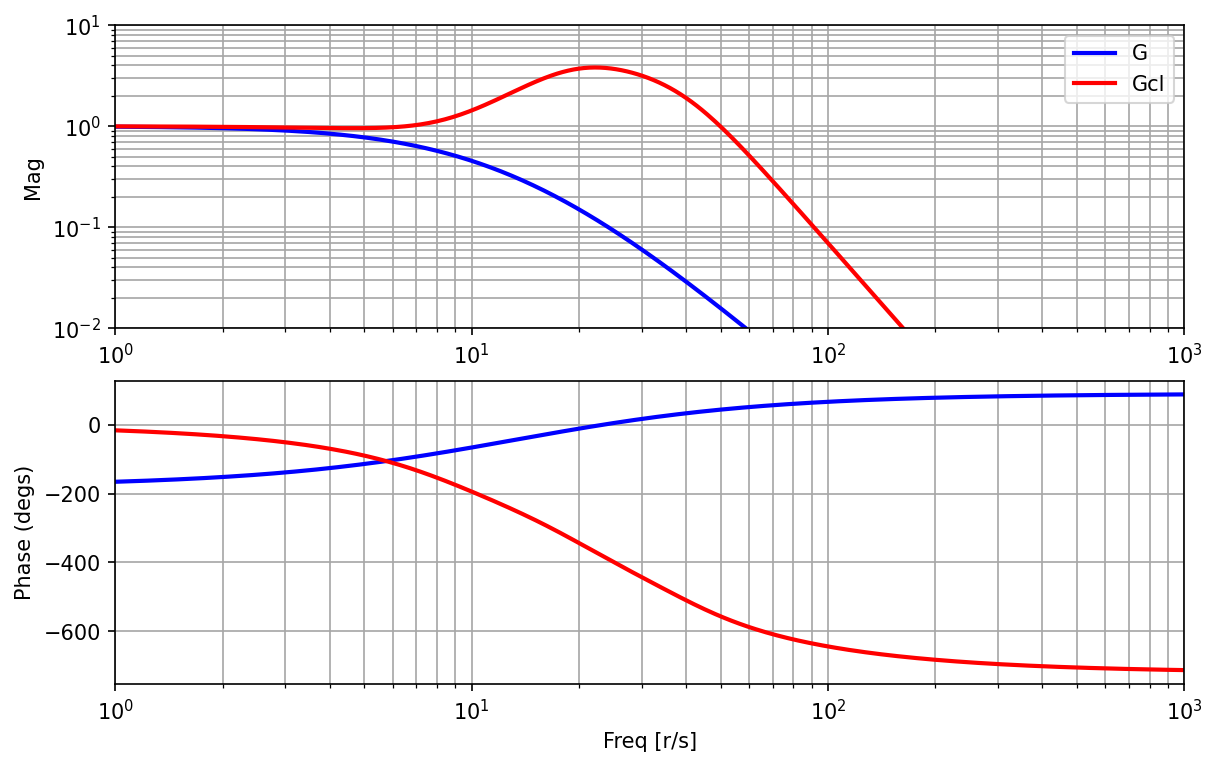

array([-20.+34.64101615j, -20.-34.64101615j, -40. +0.j        ,
       -10.+17.32050808j, -10.-17.32050808j, -20. +0.j        ])

In [19]:
G3 = ss(tf(8*14*20,np.convolve([1, -8],np.convolve([1, -14],[1, -20]))))
file_name = 'examp3'
nx = len(G3.poles())
zz,pp,kk = butter(nx,20,output='zpk',analog=True)
pe = [2*p for p in pp]
Gc3,Gcl3 = DOFB(G3,pp,pe,file_name=file_name, w=np.logspace(0,3,400),use_y_lims=False)
Gcl3.poles()

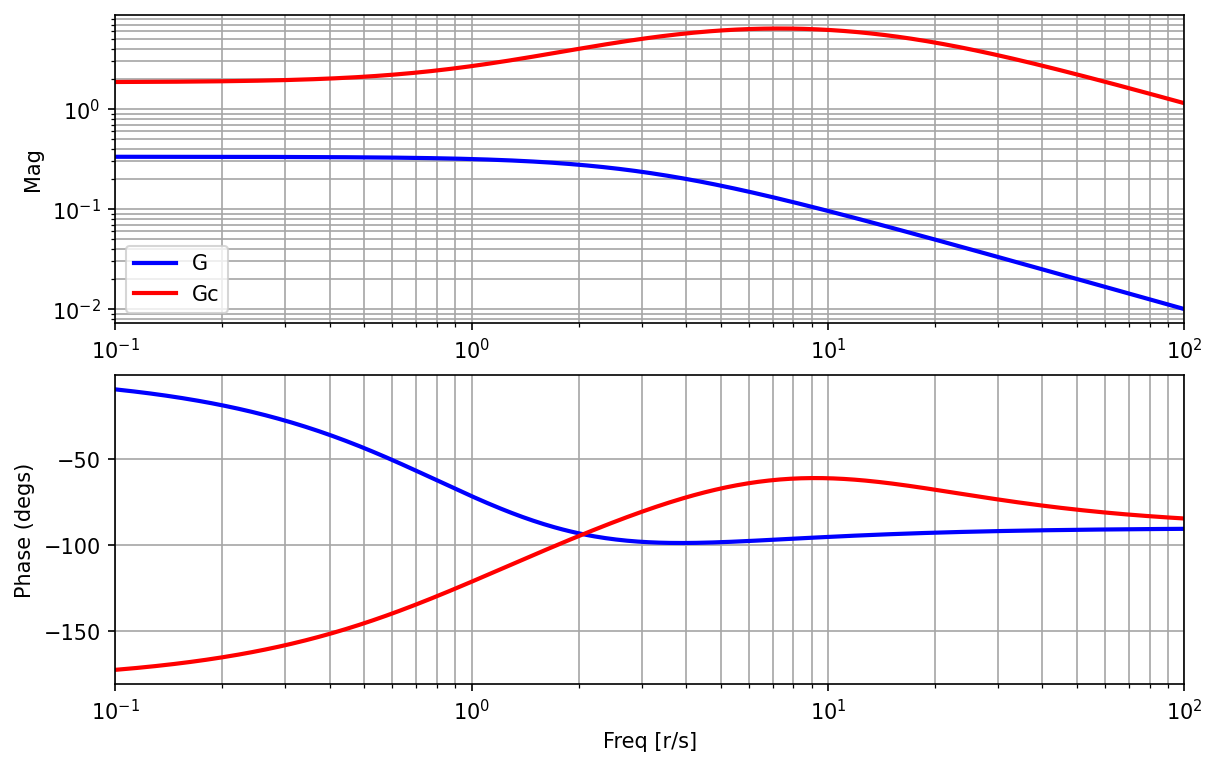

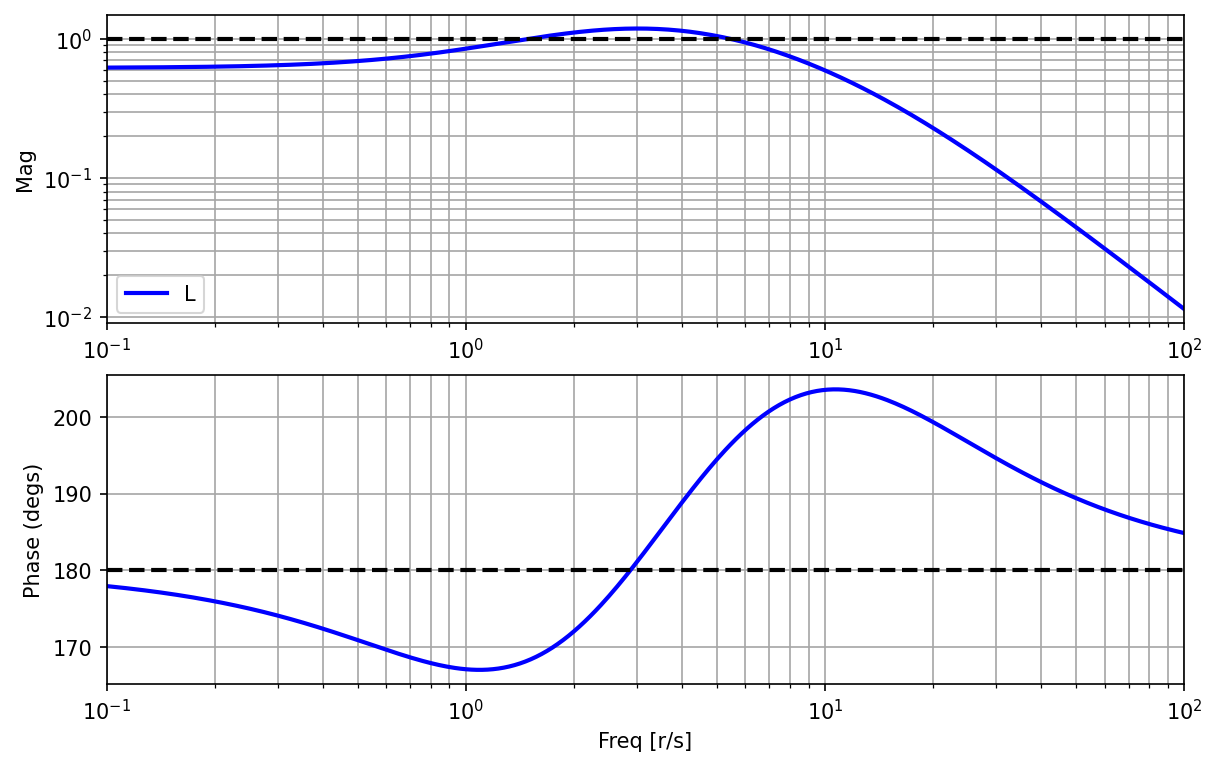

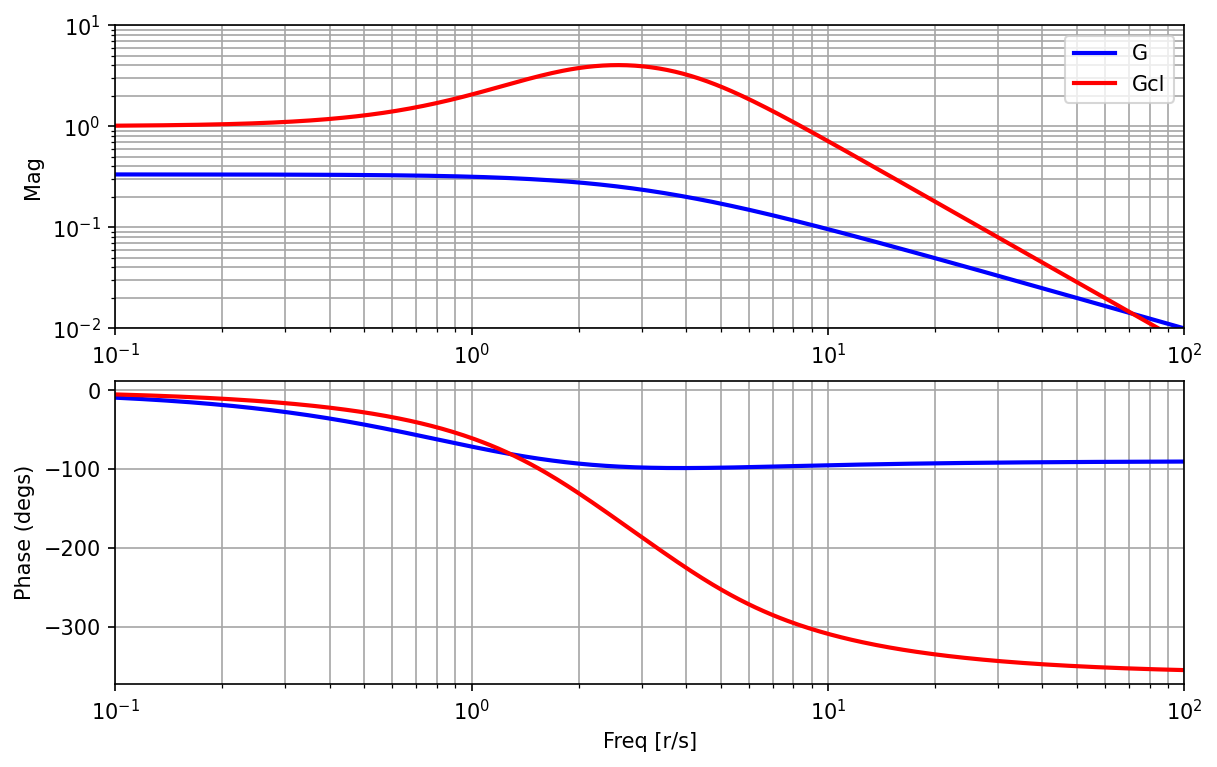

array([-2.82842712+2.82842712j, -2.82842712-2.82842712j,
       -1.41421356+1.41421356j, -1.41421356-1.41421356j])

In [20]:
G4 = ss(tf((1,-1),(1,-2,-3)))
file_name = 'examp4'
nx = len(G4.poles())
zz,pp,kk = butter(nx,2,output='zpk',analog=True)
pe = [2*p for p in pp]
Gc4, Gcl4 = DOFB(G4,pp,pe,file_name=file_name, w=np.logspace(-1,2,400),use_y_lims=False)
Gcl4.poles()

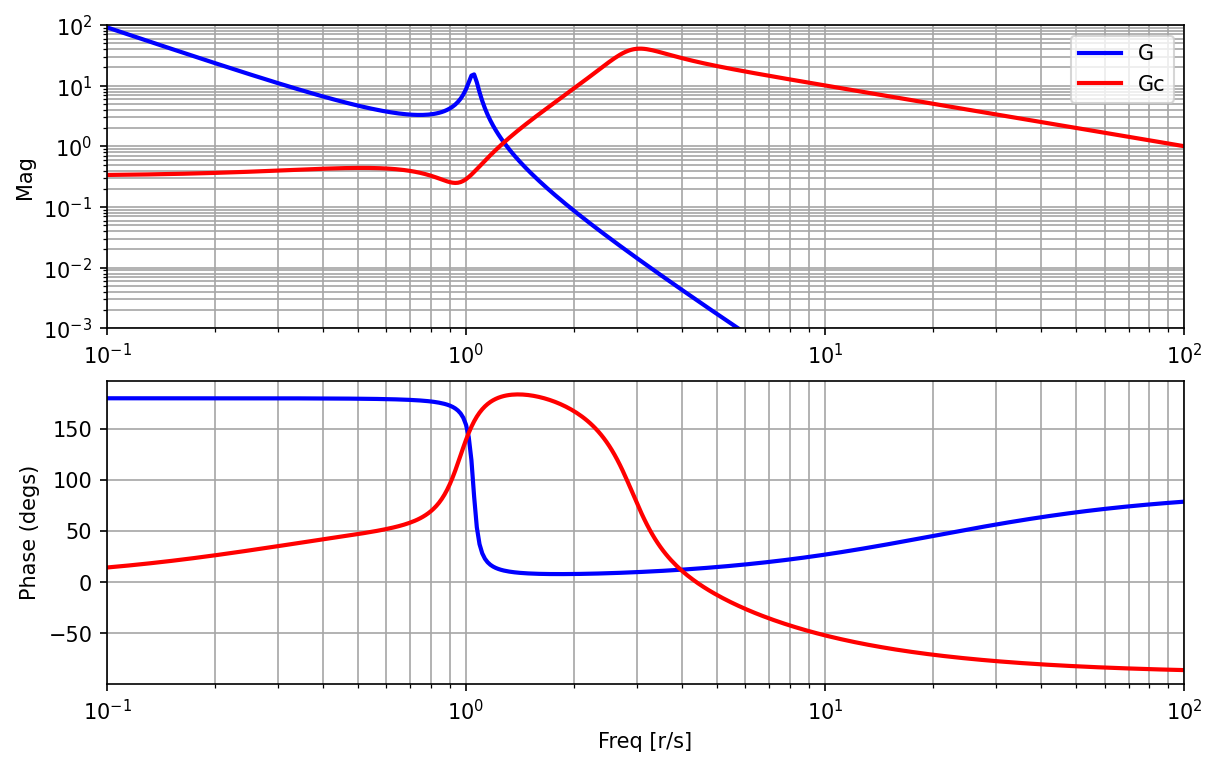

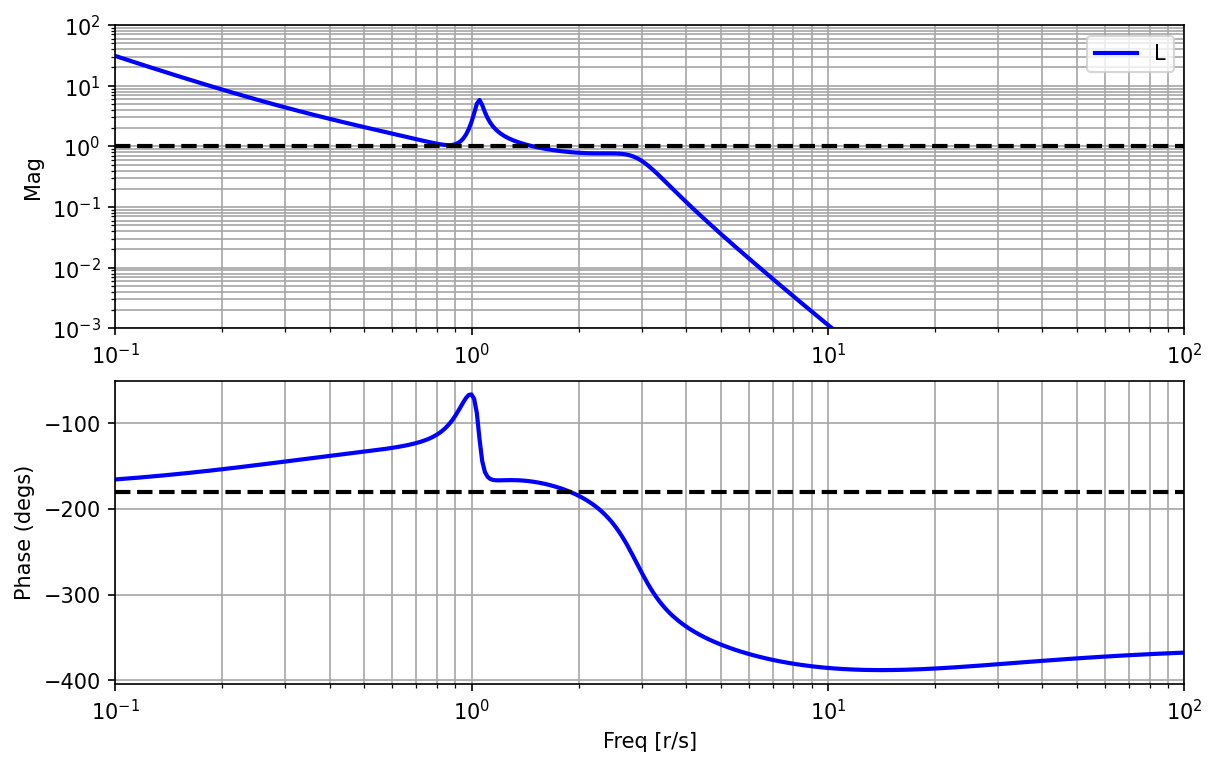


Found breakin/out at K = 1.011
At possible locations s = -1.352


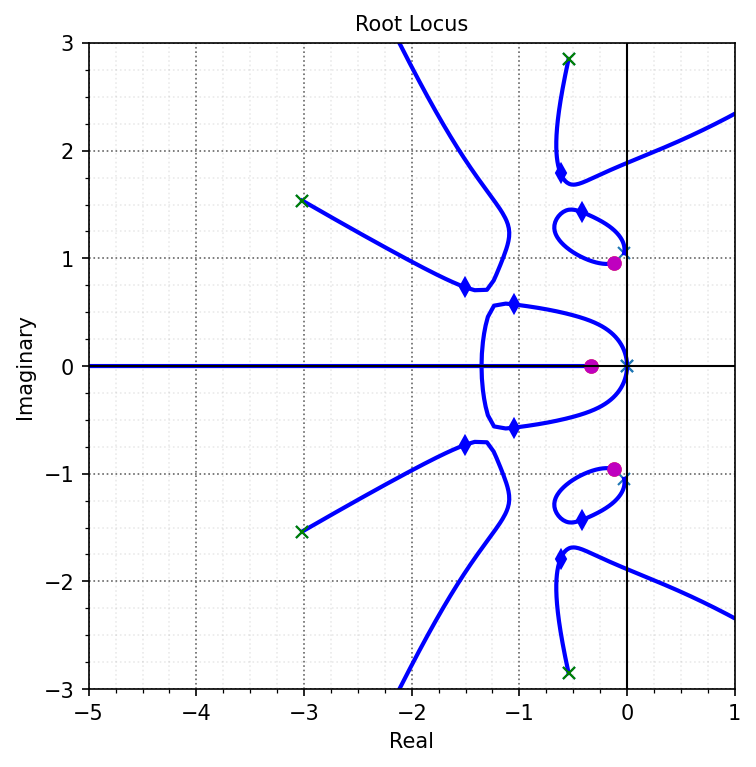

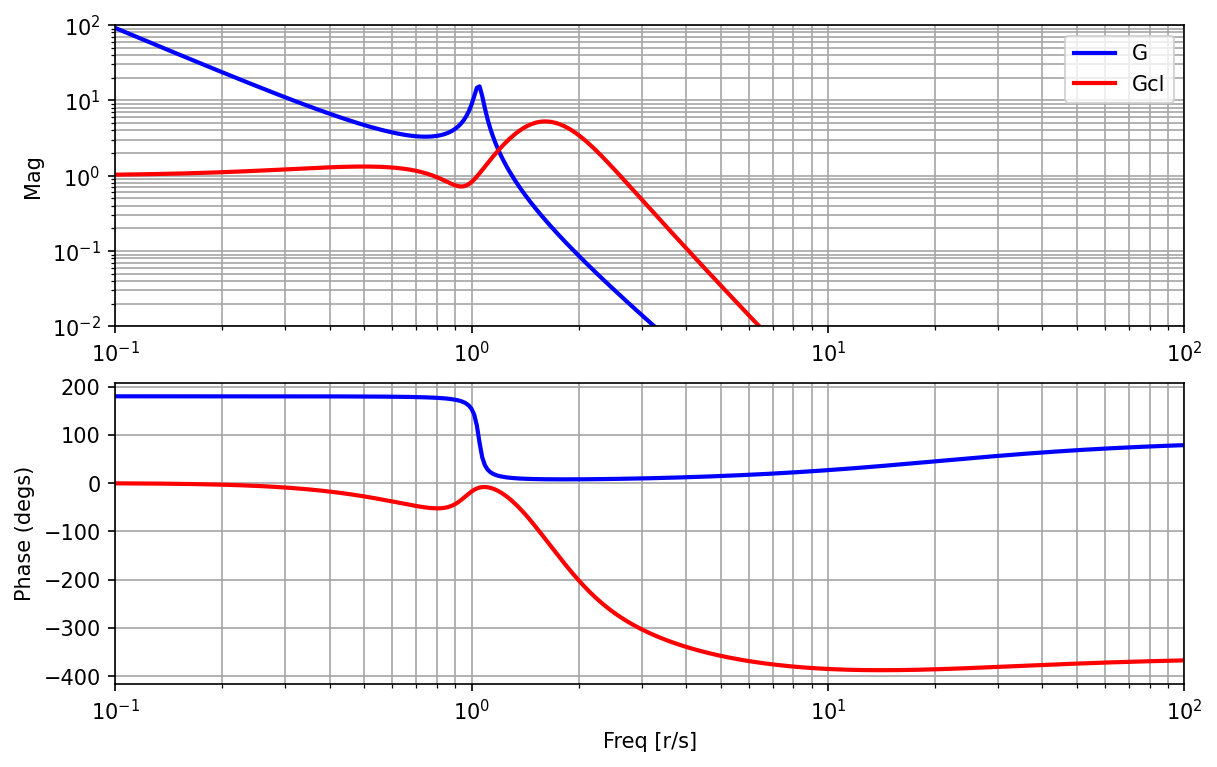

In [21]:
# Combined estimator/regulator design for a simple satellite model
# follows FPE 9.2 (fourth edition)
# Jonathan How
#
kk = 0.1
bb = 0.05*np.sqrt(kk/10)
J1 = 1
J2 = 0.1
a = np.array([[0, 1, 0, 0],[-kk/J2, -bb/J2, kk/J2, bb/J2],[0, 0, 0, 1],[kk/J1, bb/J1, -kk/J1, -bb/J1]])
nx = a.shape[0]
b = np.array([0, 0, 0, 1/J1]).reshape(nx,1);
c = np.array([1, 0, 0, 0])
d = 0

# design DOFB controller
k,_,_ = lqr(a,b,c.reshape(nx,1)*c,.1)
k = np.squeeze(np.asarray(k))
l,_,_ = lqr(a.transpose(),c.reshape(nx,1),b*b.reshape(1,nx),.01)
l = np.squeeze(np.asarray(l))
l = l.reshape(nx,1)
#
# For state space for G_c(s)
#
ac = a-b*k-l*c
bc = l
cc = k
dc = 0

G = ss(a,b,c,d);
Gc = ss(ac,bc,cc,dc)
L = G*Gc

w = np.logspace(-1,2,400)
Gf = G(w*j)
Gcf = Gc(j*w)
Lf = L(j*w)
#
# loop dynamics L = G Gc
#
al = np.vstack((np.hstack((a,b*cc)),np.hstack((np.zeros((nx,nx)),ac))))
bl = np.vstack((np.zeros((nx,1)), bc ))
cl = np.hstack((c.reshape(1,nx), np.zeros((1,nx)) ))
dl = 0
L = ss2tf(al,bl,cl,dl)
#
# closed-loop dynamics
# unity gain wrapped around loop L
#
acl = al - bl*cl
bcl = bl 
ccl = cl
dcl = d
# scale closed-loop to get zero SS error
N = np.linalg.inv(ccl@np.linalg.inv(-acl)@bcl)

Gcl = ss2tf(acl,bcl*N,ccl,dcl*N)
scl = Gcl.poles()
sc = Gc.poles()
zc = Gc.zeros()
Gclf = Gcl(j*w)

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gcf),'r',label=r'Gc')
ax[1].semilogx(w,np.unwrap(np.angle(Gcf))*r2d,'r',label=r'Gc')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_0.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Lf),'b',label=r'L')
ax[1].semilogx(w,np.unwrap(np.angle(Lf))*r2d,'b',label=r'L')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].axhline(y=1,c='k',ls='--')
ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_1.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rlist, klist = rlocus(L, kvect=Root_Locus_gains(L,Krange = np.logspace(-3, 3, num=10000)), plotstr='b-', grid=False,ax=ax)
plt.plot(np.real(scl),np.imag(scl),'bd')
plt.plot(np.real(sc),np.imag(sc),'gx')
plt.plot(np.real(zc),np.imag(zc),'mo')
ax.set_aspect('equal')
ax.set_xlim([-5, 1]);
ax.set_ylim([-3, 3])
nicegrid(ax)
savefig("figs/DOFB_sat_2.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Gclf),'r',label=r'Gcl')
ax[1].semilogx(w,np.unwrap(np.angle(Gclf))*r2d,'r',label=r'Gcl')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-2,100)
savefig("figs/DOFB_sat_3.pdf", dpi=600)
plt.show()

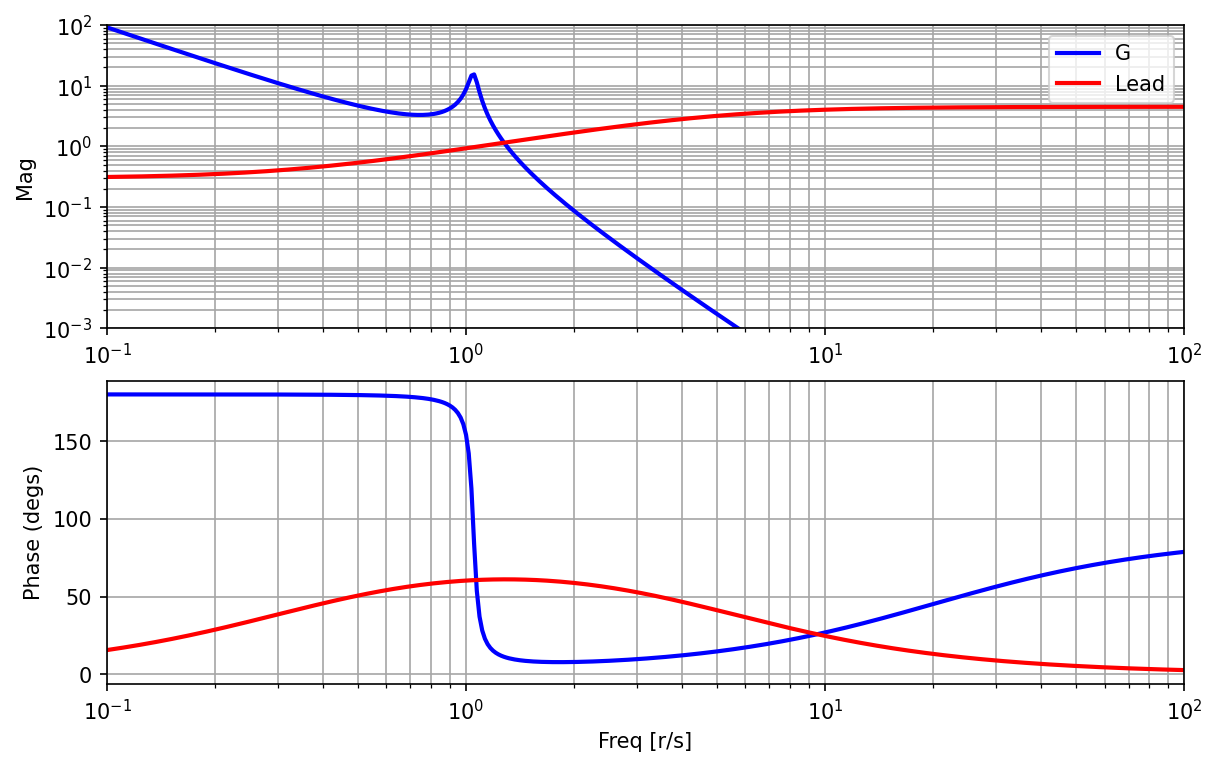

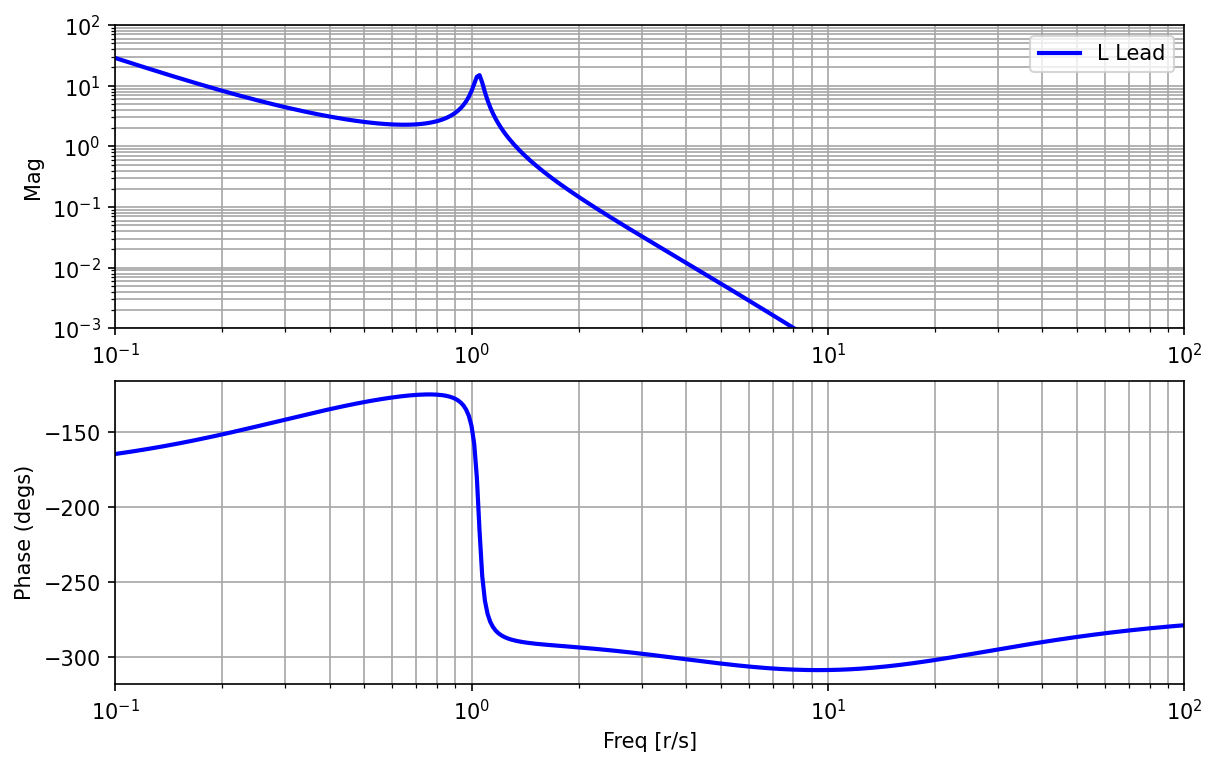

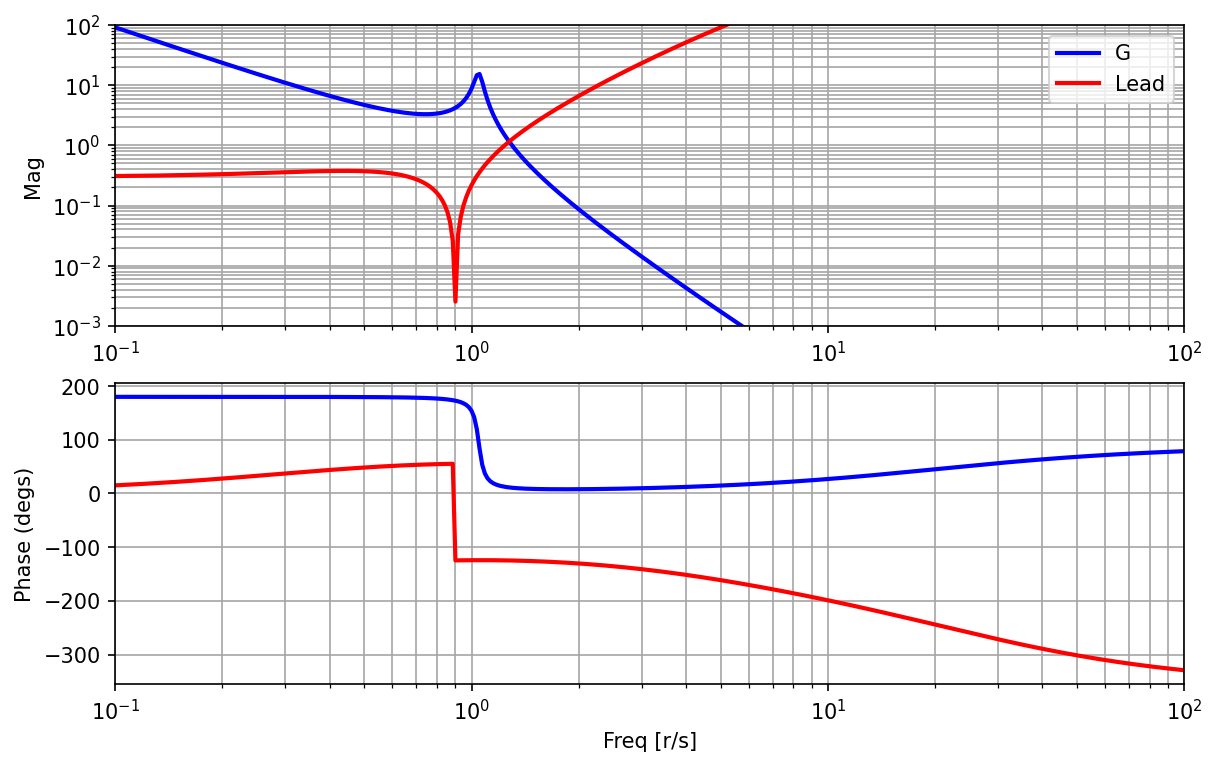

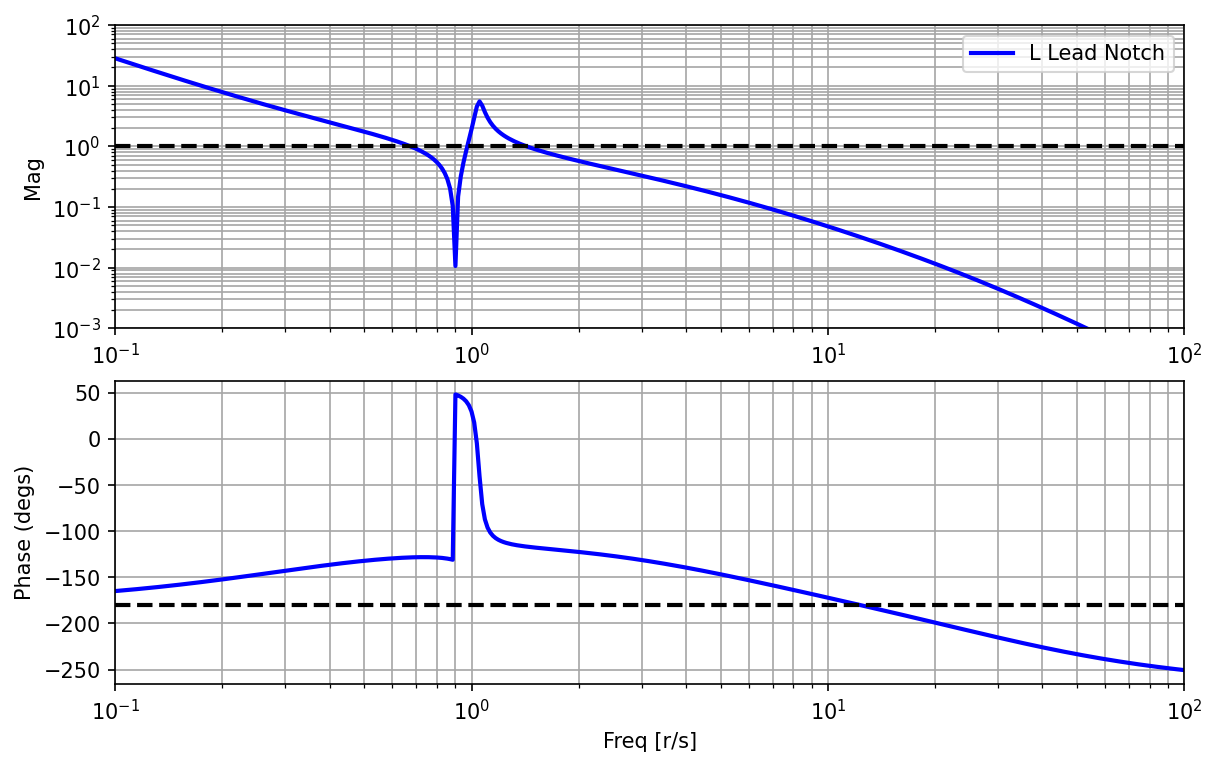

Gain augmentation failed


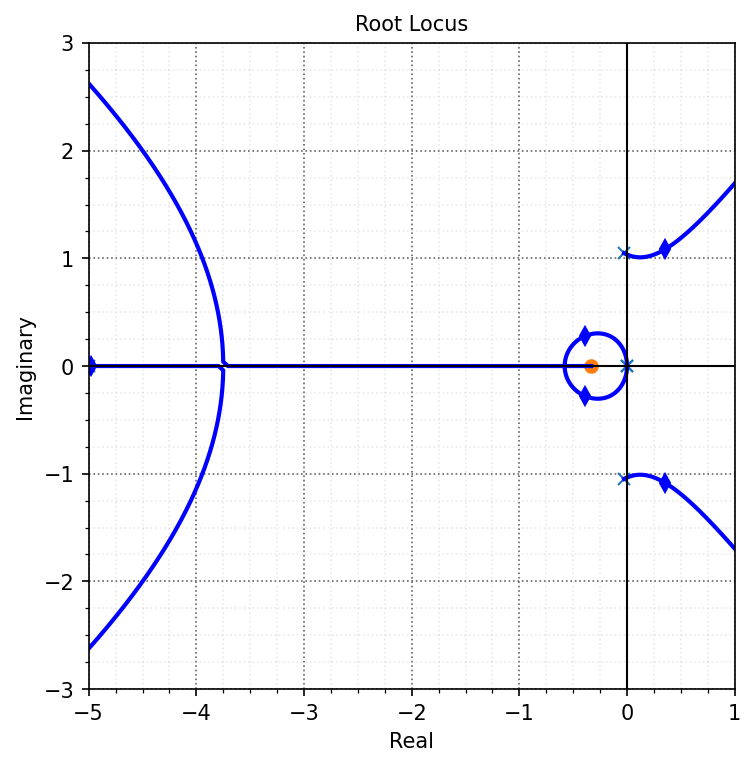

Gain augmentation failed


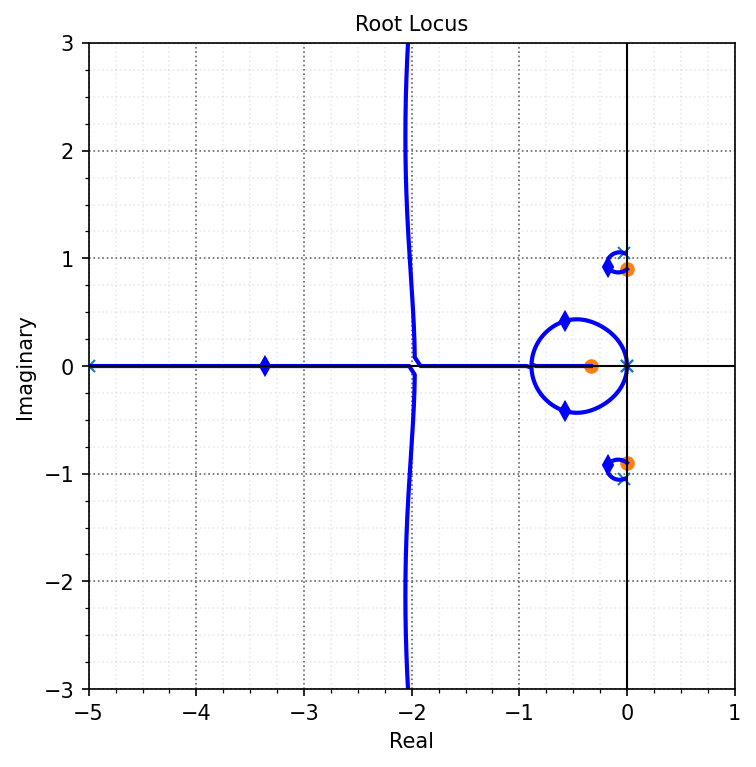

In [22]:
#
# try classical design
#
Klead = 1.5*tf([3, 1],[1, 5]);
Kleadf = Klead(w*j)
LLead = G*Klead
LLeadf = LLead(j*w)
Gcl_Lead = feedback(LLead,1)
scl_Lead = Gcl_Lead.poles()

KleadNotch = Klead*tf([1, 0, .9**2],[1, 2*25, 25**2])/.9**2*25**2;
KleadNotchf = KleadNotch(w*j)

LLeadNotch = G*KleadNotch
LLeadNotchf = LLeadNotch(j*w)
Gcl_LeadNotch = feedback(LLeadNotch,1)
scl_LeadNotch = Gcl_LeadNotch.poles()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(Kleadf),'r',label=r'Lead')
ax[1].semilogx(w,np.unwrap(np.angle(Kleadf))*r2d,'r',label=r'Lead')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_6.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(LLeadf),'b',label=r'L Lead')
ax[1].semilogx(w,np.unwrap(np.angle(LLeadf))*r2d,'b',label=r'L Lead')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_6a.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf),'b',label=r'G')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*r2d,'b',label=r'G')
ax[0].loglog(w,np.abs(KleadNotchf),'r',label=r'Lead')
ax[1].semilogx(w,np.unwrap(np.angle(KleadNotchf))*r2d,'r',label=r'Lead')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_7.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(LLeadNotchf),'b',label=r'L Lead Notch')
ax[1].semilogx(w,np.unwrap(np.angle(LLeadNotchf))*r2d,'b',label=r'L Lead Notch')
ax[1].set_xlabel('Freq [r/s]')
ax[0].set_ylabel('Mag')
ax[1].set_ylabel('Phase (degs)')
ax[0].grid(True, which="both", ls="-",color='0.65')
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[0].axhline(y=1,c='k',ls='--')
ax[1].axhline(y=-180,c='k',ls='--')
ax[0].legend()
ax[0].set_ylim(1e-3,100)
savefig("figs/DOFB_sat_8.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rlist, klist = rlocus(LLead, kvect=Root_Locus_gains(LLead,Krange = np.logspace(-3, 3, num=10000)), plotstr='b-', grid=False,ax=ax)
ax.set_aspect('equal')
ax.set_xlim([-5, 1]);
ax.set_ylim([-3, 3])
plt.plot(np.real(scl_Lead),np.imag(scl_Lead),'bd')
nicegrid(ax)
savefig("figs/DOFB_sat_9.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
rlist, klist = rlocus(LLeadNotch, kvect=Root_Locus_gains(LLeadNotch,Krange = np.logspace(-2, 2, num=10000)), plotstr='b-', grid=False,ax=ax)
ax.set_aspect('equal')
ax.set_xlim([-5, 1]);
ax.set_ylim([-3, 3])
plt.plot(np.real(scl_LeadNotch),np.imag(scl_LeadNotch),'bd')
nicegrid(ax)
savefig("figs/DOFB_sat_10.pdf", dpi=600)
plt.show()
